# Minimal EnergyPlus 23.2 ↔ Python BRCM comparison

This notebook develops the workflow one stage at a time: run EnergyPlus, generate the BRCM thermal network, configure external heat-flux (EHF) models, map EnergyPlus columns to BRCM identifiers, compose the BuildingModel, simulate, and compare. The IDF defines the RC network but does not by itself define BRCM forcing trajectories.

In [1]:
from pathlib import Path
import copy
import re, shutil, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REPO = Path.cwd().parents[1]
EPD = Path.cwd().parents[3] / '_phd' / 'Y3'
sys.path[:0] = [str(REPO / 'src'), str(EPD / 'src')]
from ReIDF import IDFout, run_IDF, md_IDFdt
import brcm

CASE_NAME = '1ZoneUncontrolled1'
IDF = REPO / '_E+' / f'{CASE_NAME}.idf'
IDD = REPO / '_E+/idd/23.2/Energy+.idd'
EPW = EPD / 'src' / '_base/epw/ED-TMYx.2023.epw'
ENERGYPLUS = Path('/Applications/EnergyPlus-23-2-0/energyplus') if sys.platform == 'darwin' else Path('C:/EnergyPlusV23-2-0/EnergyPlus.exe')
WORK = REPO / 'pre_test/outputs/validation/eplus_23_2_minimal' / CASE_NAME
WORK.mkdir(parents=True, exist_ok=True)
TS_HRS = 0.25
PERIODS = {
    'January': ('2023-01-01', '2023-01-05'),
    'April': ('2023-04-01', '2023-04-05'),
    'July': ('2023-07-01', '2023-07-05'),
    'October': ('2023-10-01', '2023-10-05'),
}
START_DATE, END_DATE = PERIODS['April']  # Step-by-step worked example below.

## 1 — Run EnergyPlus and export forcing/validation variables

EnergyPlus is run first to provide a common weather period, gain signals, and validation trajectories. Some outputs become BRCM forcing inputs; others are diagnostics only. Surface temperatures must not drive the final independent comparison.

The disposable copy is changed to a weather-only run. `md_IDFdt()` sets the requested RunPeriod, while `SimulationControl` is changed from design-day-only to weather-file-only so sizing environments cannot be concatenated into the CSV.

In [2]:
working_idf = WORK / IDF.name
shutil.copy2(IDF, working_idf)
md_IDFdt(working_idf, start_date=START_DATE, end_date=END_DATE)

lines = working_idf.read_text(encoding='utf-8').splitlines(keepends=True)
start = next(i for i, line in enumerate(lines) if line.strip().casefold().startswith('simulationcontrol,'))
fields, index = [], start + 1
while index < len(lines):
    fields.append(index)
    if ';' in lines[index]: break
    index += 1
for position, value in ((3, 'No'), (4, 'Yes')):
    row = fields[position]
    lines[row] = re.sub(r'^(\s*)(?:Yes|No)(\s*[,;])', rf'\g<1>{value}\g<2>', lines[row], flags=re.I)
working_idf.write_text(''.join(lines), encoding='utf-8')

window_data = (ENERGYPLUS.parent / 'DataSets' / 'Window5DataFile.dat').resolve()
text = working_idf.read_text(encoding='utf-8').replace(r'..\datasets\Window5DataFile.dat', str(window_data))
working_idf.write_text(text, encoding='utf-8')
with working_idf.open('a', encoding='utf-8') as stream:
    stream.write(r'''
Output:Variable,*,Site Outdoor Air Drybulb Temperature,timestep;
Output:Variable,*,Site Ground Temperature,timestep;
Output:Variable,*,Site Surface Ground Temperature,timestep;
Output:Variable,*,Site Deep Ground Temperature,timestep;
Output:Variable,*,Site Simple Factor Model Ground Temperature,timestep;
Output:Variable,*,Site Direct Solar Radiation Rate per Area,timestep;
Output:Variable,*,Site Diffuse Solar Radiation Rate per Area,timestep;
Output:Variable,*,Zone Mean Air Temperature,timestep;
Output:Variable,*,Surface Inside Face Temperature,timestep;
Output:Variable,*,Surface Outside Face Temperature,timestep;
Output:Variable,*,Surface Inside Face Convection Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Convection Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Convection Heat Gain Rate,timestep;
Output:Variable,*,Surface Outside Face Outdoor Air Drybulb Temperature,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Net Thermal Radiation Heat Gain Rate,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Rate,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Air Heat Transfer Rate,timestep;
Output:Variable,*,Site Sky Temperature,timestep;
Output:Variable,*,Surface Outside Face Incident Solar Radiation Rate per Area,timestep;
Output:Variable,*,Surface Outside Face Solar Radiation Heat Gain Rate,timestep;
Output:Variable,*,Surface Window Transmitted Solar Radiation Rate,timestep;
Output:Variable,*,Surface Window Net Heat Transfer Rate,timestep;
Output:Variable,*,Surface Window Heat Gain Rate,timestep;
Output:Variable,*,Surface Window Heat Loss Rate,timestep;
Output:Variable,*,Surface Window Frame Heat Gain Rate,timestep;
Output:Variable,*,Surface Window Frame Heat Loss Rate,timestep;
Output:Variable,*,Zone Windows Total Transmitted Solar Radiation Rate,timestep;
Output:Variable,*,Zone Total Internal Convective Heating Rate,timestep;
Output:Variable,*,Zone Total Internal Radiant Heating Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Outdoor Air Transfer Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Interzone Air Transfer Rate,timestep;
Output:Variable,*,Zone Air Heat Balance System Air Transfer Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Surface Convection Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Internal Convective Heat Gain Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Air Energy Storage Rate,timestep;
''')
IDFout(working_idf, ['CSV', 'MTR', 'Tabular', 'RDD'])
eplus_dir = Path(run_IDF(working_idf, EPW, ENERGYPLUS))
eplus = pd.read_csv(eplus_dir / 'eplusout.csv')
time_col = next(column for column in eplus if 'date/time' in column.casefold().replace(' ', ''))
print(f'EnergyPlus: {len(eplus)} samples, {len(eplus.columns) - 1} signals')

Simulation completed successfully.
Simulation Output Folder: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/pre_test/outputs/validation/eplus_23_2_minimal/1ZoneUncontrolled1/1ZoneUncontrolled1
EnergyPlus: 480 samples, 100 signals


## 2 — Generate the BRCM ThermalModel from the IDF

This stage creates only `dx/dt = A x + Bq q`. `A` is in s⁻¹, `Bq` is K/J, and `Xcap` is J/K. State and heat-flux ordering is given by the model identifiers. Ambient temperature, solar gains, internal gains, HVAC, and trajectories are not yet defined.

In [3]:
conversion = brcm.convert_idf_to_brcm_data(IDF, idd_path=IDD)
thermal_data = brcm.conversion_to_thermal_model_data(conversion)
thermal_model = brcm.generate_thermal_model(thermal_data)

## 3 — Configure the EHF models

All EHF constructors use `(thermal_data, thermal_model, identifier, source_file)`.

| EHF class | Generated signal | Expected units | Convention |
|---|---|---|---|
| `InternalGains` | `v_IG_<name>` | W/m² | multiplied by zone floor area |
| `BuildingHull` | `v_Tamb`, optional `v_Tgnd`, `v_solGlobFac_<name>` | °C and W/m² | ambient conduction, solar, windows and infiltration |
| `Radiators` | `u_rad_<name>` | W/m² | positive heating |
| `BEHeatfluxes` | `u_BEH_<name>_heat/cool` | W/m² | targets a one-based massive layer |
| `AHU` | identifier-prefixed mass flow/heating/cooling | kg/s, W, °C | mass-flow × temperature terms are bilinear |

This uncontrolled example uses `BuildingHull` and `InternalGains`. Window incident irradiance is an input; EnergyPlus transmitted-solar and net-window-heat columns remain validation signals. Opaque solar is unavailable here because the outdoor constructions are massless and the Python opaque-solar path requires a massive envelope state.

In [4]:
ehf_dir = WORK / 'ehf'
ehf_dir.mkdir(parents=True, exist_ok=True)
window_elements = [element for element in thermal_data.building_elements if element.window_identifier]
ep_window_by_parent = {window.parent_surface.casefold(): window for window in conversion.normalized_model.windows}
hull_rows = ['facade_solar_group;buildingelement_identifier;disturbance_identifier;absorptance;', 'window_solar_group;buildingelement_identifier;disturbance_identifier;control_identifier;secondary_gains_fraction;']
for element in window_elements:
    hull_rows.append(f';{element.identifier};{element.identifier};;1;')
hull_rows.append('infiltration_specification;zone_identifier;airchangerate;;;')
for zone in thermal_data.zones:
    hull_rows.append(f';{zone.identifier};0;;;')
hull_file = ehf_dir / 'building_hull.csv'
hull_file.write_text('\n'.join(hull_rows) + '\n', encoding='utf-8')
gains_file = ehf_dir / 'internal_gains.csv'
gains_file.write_text('zone_identifier;disturbance_identifier;\n' + ''.join(f'{zone.identifier};{zone.identifier};\n' for zone in thermal_data.zones), encoding='utf-8')
building_hull = brcm.BuildingHull(thermal_data, thermal_model, 'hull', hull_file)
internal_gains = brcm.InternalGains(thermal_data, thermal_model, 'gains', gains_file)
ehf_models = [building_hull, internal_gains]
[(model.EHF_identifier, model.identifiers.u, model.identifiers.v) for model in ehf_models]

[('hull', [], ['v_Tamb', 'v_solGlobFac_B0001']), ('gains', [], ['v_IG_Z0001'])]

## 4 — Map EnergyPlus outputs to EHF inputs

Mapping is performed by identifier rather than matrix position. Temperature columns remain °C. Internal convective plus radiant heat is exported in W and divided by zone area because `InternalGains` expects W/m²; the EHF multiplies it by area to recover W. No manual W→J conversion is required because discretization integrates W over seconds through `Bq` in K/J.

In [5]:
def ep_column(variable, key=None):
    matches = [column for column in eplus if variable.casefold() in column.casefold() and (key is None or f'{key}:{variable}'.casefold() in column.casefold())]
    if len(matches) != 1: raise KeyError(f'Expected one column for {key!r}/{variable!r}; found {matches}')
    return matches[0]

forcing_by_identifier = {'v_Tamb': eplus[ep_column('Site Outdoor Air Drybulb Temperature')].to_numpy(float)}
mapping_rows = [('v_Tamb', ep_column('Site Outdoor Air Drybulb Temperature'), '°C', 'positive ambient conductance')]
if 'v_Tgnd' in building_hull.identifiers.v:
    forcing_by_identifier['v_Tgnd'] = eplus[ep_column('Site Ground Temperature')].to_numpy(float)
for element in window_elements:
    parent = element.description.split(':', 1)[1]
    ep_window = ep_window_by_parent[parent.casefold()]
    column = ep_column('Surface Outside Face Incident Solar Radiation Rate per Area', ep_window.name)
    identifier = f'v_solGlobFac_{element.identifier}'
    forcing_by_identifier[identifier] = eplus[column].to_numpy(float)
    mapping_rows.append((identifier, column, 'W/m²', 'positive solar gain'))
for zone in thermal_data.zones:
    convective = ep_column('Zone Total Internal Convective Heating Rate', zone.description)
    radiant = ep_column('Zone Total Internal Radiant Heating Rate', zone.description)
    identifier = f'v_IG_{zone.identifier}'
    forcing_by_identifier[identifier] = (eplus[convective].to_numpy(float) + eplus[radiant].to_numpy(float)) / thermal_data.eval_str(zone.area)
    mapping_rows.append((identifier, f'{convective} + {radiant}', 'W → W/m²', 'positive internal gain'))
display(pd.DataFrame(mapping_rows, columns=['BRCM identifier', 'EnergyPlus source', 'units', 'sign']))

,BRCM identifier,EnergyPlus source,units,sign
0,v_Tamb,Environment:Site Outdoor Air Drybulb Temperatu...,°C,positive ambient conductance
1,v_solGlobFac_B0001,ZN001:WALL001:WIN001:Surface Outside Face Inci...,W/m²,positive solar gain
2,v_IG_Z0001,ZONE ONE:Zone Total Internal Convective Heatin...,W → W/m²,positive internal gain


## 5 — Generate the BuildingModel

The BuildingModel composes the existing ThermalModel with the EHF instances. Its sorted identifier lists define row order in `U` and `V`; trajectories always use identifiers on rows and time on columns. Sampling time is expressed in hours.

In [6]:
building_model = brcm.BuildingModel(thermal_model, ehf_models)
building_model.discretize(TS_HRS)
missing = set(building_model.identifiers.v) - set(forcing_by_identifier)
extra = set(forcing_by_identifier) - set(building_model.identifiers.v)
if missing or extra: raise RuntimeError(f'Forcing mismatch: missing={missing}, extra={extra}')
U = np.zeros((len(building_model.identifiers.u), len(eplus)))
V = np.vstack([forcing_by_identifier[name] for name in building_model.identifiers.v])
print('u row order:', building_model.identifiers.u, U.shape)
print('v row order:', building_model.identifiers.v, V.shape)

u row order: [] (0, 480)
v row order: ['v_IG_Z0001', 'v_Tamb', 'v_solGlobFac_B0001'] (3, 480)


## 6 — Simulate BRCM independently

All states begin at the first EnergyPlus zone-air temperature, and each zone state is set to its matching value. The run is open loop: EnergyPlus surface or future zone temperatures are not fed back into BRCM.

In [7]:
zone_pairs = [(zone.identifier, zone.description, ep_column('Zone Mean Air Temperature', zone.description)) for zone in thermal_data.zones]
x_index = {name: index for index, name in enumerate(building_model.identifiers.x)}
initial_temperature = np.mean([eplus[column].iloc[0] for _, _, column in zone_pairs])
x0 = np.full((len(building_model.identifiers.x), 1), initial_temperature)
for zone_id, _, column in zone_pairs:
    x0[x_index[f'x_{zone_id}'], 0] = eplus[column].iloc[0]
brcm_run = brcm.simulate_building_model(building_model, x0, U, V)
print('BRCM X:', brcm_run.X.shape, 'finite:', np.isfinite(brcm_run.X).all())

BRCM X: (2, 480) finite: True


## 7 — Compare against EnergyPlus

This is the independent comparison. Remaining differences can include omitted opaque solar on massless constructions, dynamic EnergyPlus exterior films and long-wave exchange, simplified radiant-gain distribution, and infiltration assumptions.

### Diagnostic decomposition (no calibration)

After the four seasonal plots, the April case is decomposed into initial-condition, exterior boundary, solar, window, internal-gain, infiltration, construction/mass, and zone-air heat-balance terms. EnergyPlus heat-balance outputs are diagnostics only and are never fed back into BRCM. The final evidence table ranks causes without changing any model parameter.


### Controlled ablation study

The copied notebook then runs cumulative, one-change-at-a-time cases on the April trajectory: **A** baseline; **B** EnergyPlus-consistent lumped window assembly properties; **C** opaque absorbed solar added through a massless sol-air boundary equivalent; and **D** resistance-position initial construction states. These are equivalence/input fixes, not fitted parameters. The original fixed-coefficient formulation remains the baseline. A dynamic EnergyPlus surface-forced exterior alternative is deliberately kept outside the equivalence ranking because it would be a model-form modification and would feed EnergyPlus surface solutions into BRCM.

Simulation completed successfully.
Simulation Output Folder: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/pre_test/outputs/validation/eplus_23_2_minimal/1ZoneUncontrolled1/seasonal/january/1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/pre_test/outputs/validation/eplus_23_2_minimal/1ZoneUncontrolled1/seasonal/april/1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/pre_test/outputs/validation/eplus_23_2_minimal/1ZoneUncontrolled1/seasonal/july/1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/pre_test/outputs/validation/eplus_23_2_minimal/1ZoneUncontrolled1/seasonal/october/1ZoneUncontrolled1


,Season,Mean bias [K],RMSE [K],MAE [K],Max |error| [K]
0,January,-0.126,0.750,0.553,2.164
1,April,-2.274,2.838,2.326,5.159
2,July,-2.783,3.270,2.843,5.750
3,October,0.161,1.162,0.982,2.518


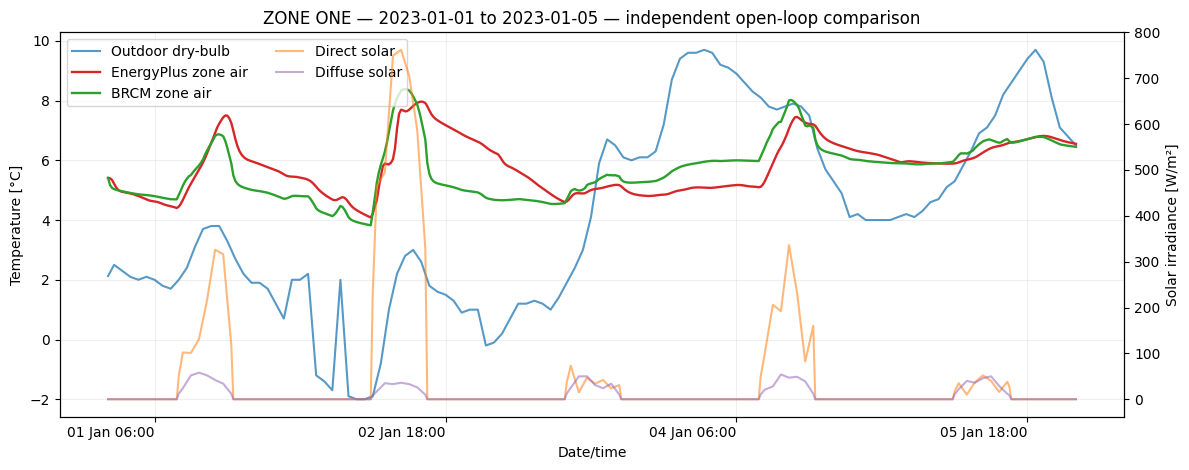

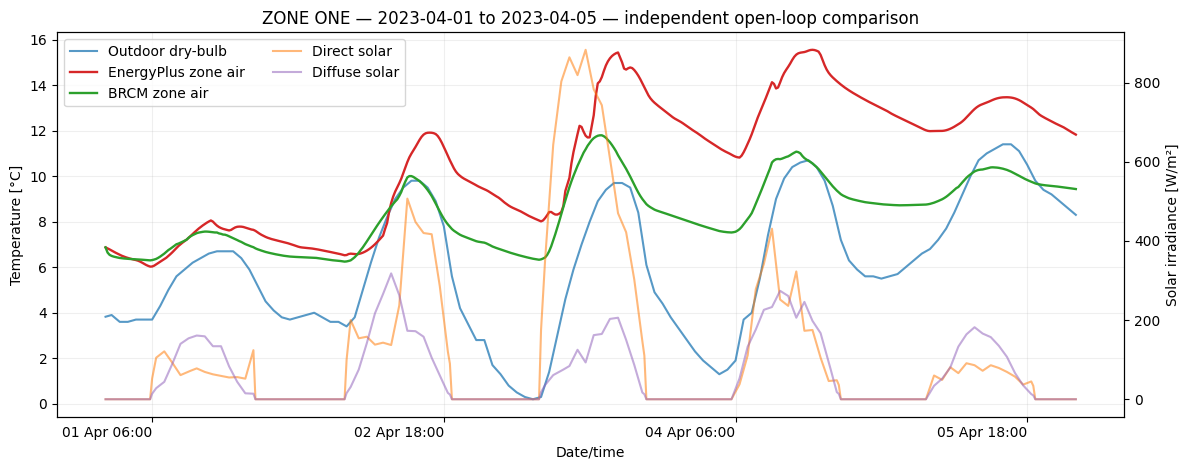

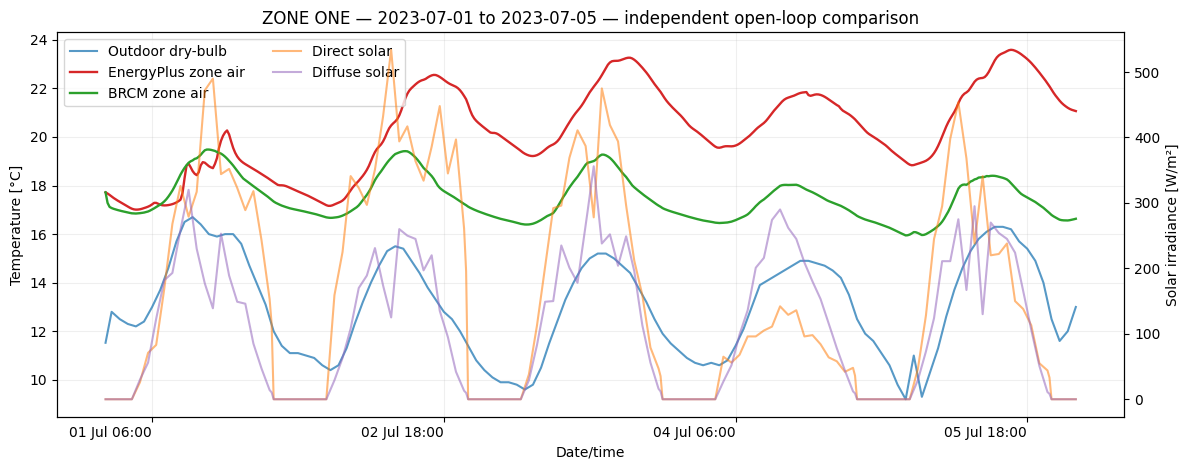

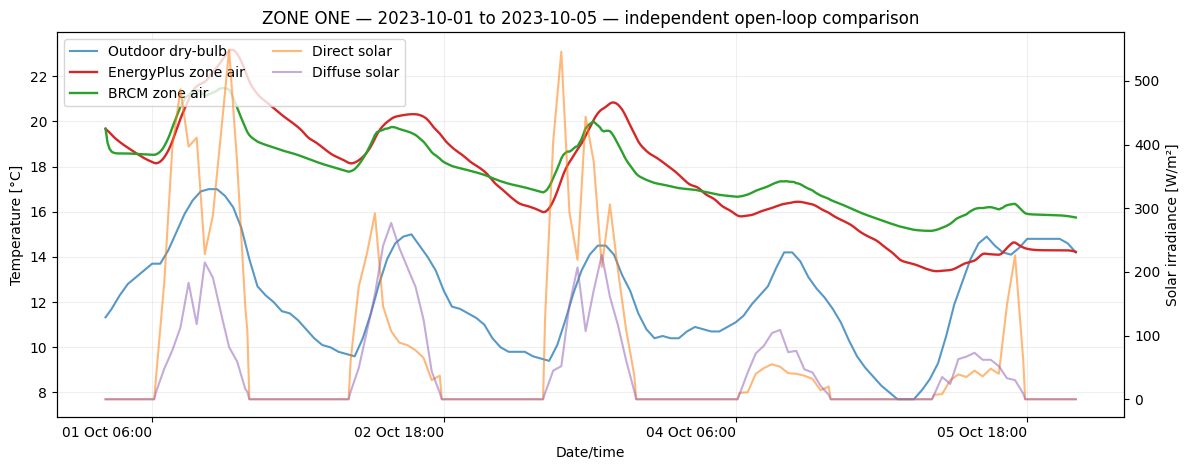

T_zone_EP(t0): 6.871467777434995
T_zone_BRCM(t0): 6.871467777434995
min/max BRCM x0: 6.871467777434995 6.871467777434995


,temperature at t0 [°C]
ZN001:WALL001:Surface Inside Face Temperature,6.554359
ZN001:WALL002:Surface Inside Face Temperature,6.547673
ZN001:WALL003:Surface Inside Face Temperature,6.540346
ZN001:WALL004:Surface Inside Face Temperature,6.539709
ZN001:FLR001:Surface Inside Face Temperature,7.215368
ZN001:ROOF001:Surface Inside Face Temperature,6.667226
ZN001:WALL001:WIN001:Surface Inside Face Temperature,5.374411
ZN001:WALL001:Surface Outside Face Temperature,2.914433
ZN001:WALL002:Surface Outside Face Temperature,2.916845
ZN001:WALL003:Surface Outside Face Temperature,2.814906


,Surface,BRCM fixed exterior h [W/m²K],BRCM total path G [W/K],EP h_conv min,EP h_conv max,EP h_sky mean,EP h_ground mean
0,Zn001:Wall001,12.5,23.740,1.559,1000.0,1.504,2.275
1,Zn001:Wall002,12.5,27.718,1.718,1000.0,1.489,2.253
2,Zn001:Wall003,12.5,27.718,1.644,1000.0,1.473,2.230
3,Zn001:Wall004,12.5,27.718,1.559,1000.0,1.492,2.257
4,Zn001:Roof001,12.5,41.028,1.758,1000.0,4.201,0.000


,Model,window area [m²],U-value [W/m²K],SHGC/g-value,frame/divider
0,BRCM converted,10.0,1.000,0.500,0.0
1,EnergyPlus glass construction,10.0,2.674,0.775,frame/divider modelled separately


Internal gains peak convective/radiant [W]: 0.0 0.0
Outdoor-air transfer min/max [W]: 0.0 0.0 (BRCM infiltration configured as 0 ACH)


,Surface,EP area [m²],BRCM area [m²],area match,construction,EP layer U [W/m²K],BRCM layer U [W/m²K],U match,layers: thickness/R/density/cp,derived EP material C [J/K],BRCM C [J/K],boundary,capacitance match
0,Zn001:Wall001,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
1,Zn001:Wall002,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
2,Zn001:Wall003,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
3,Zn001:Wall004,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
4,Zn001:Flr001,232.26,232.25760,True,FLOOR,17.040,17.040167,True,"C5 - 4 IN HW CONCRETE: t=0.1015 m, R=0.0586849...",4.423913e+07,4.423913e+07,adiabatic,True
5,Zn001:Roof001,232.26,232.25760,True,ROOF31,0.183,0.183284,True,"R31LAYER: t=0 m, R=5.456, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True


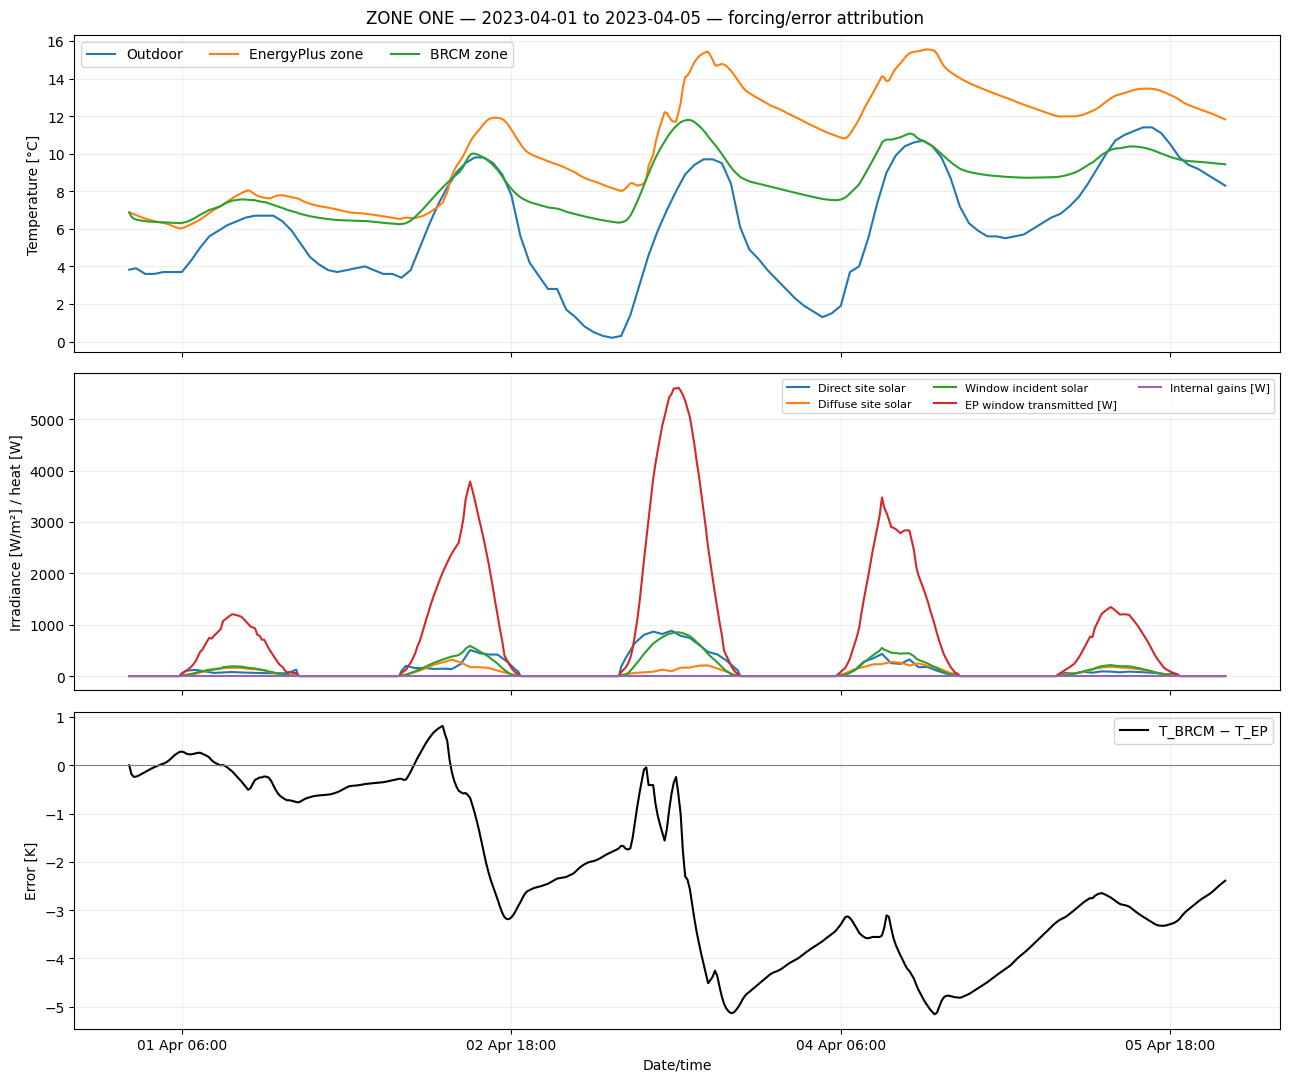

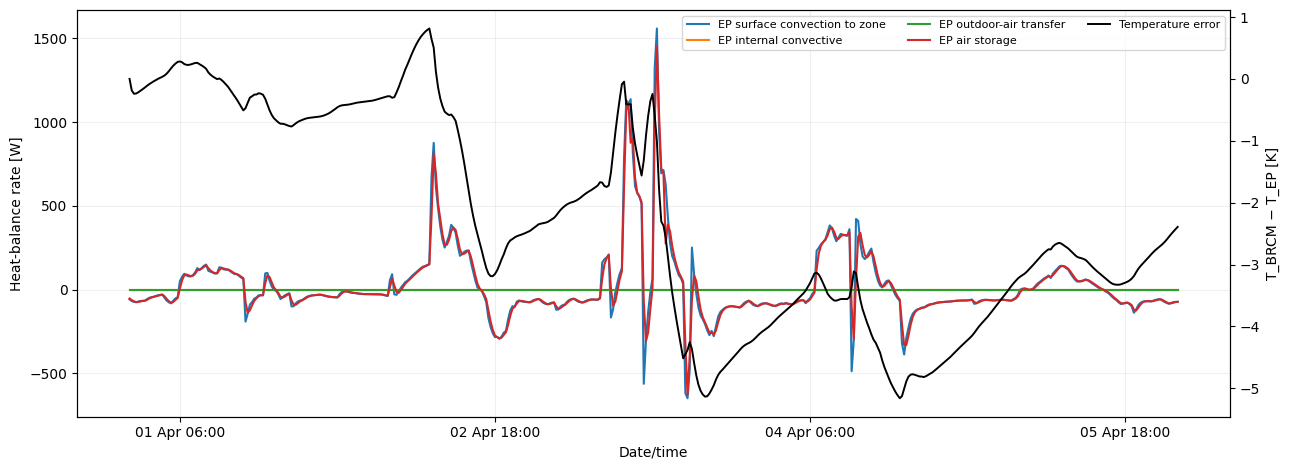

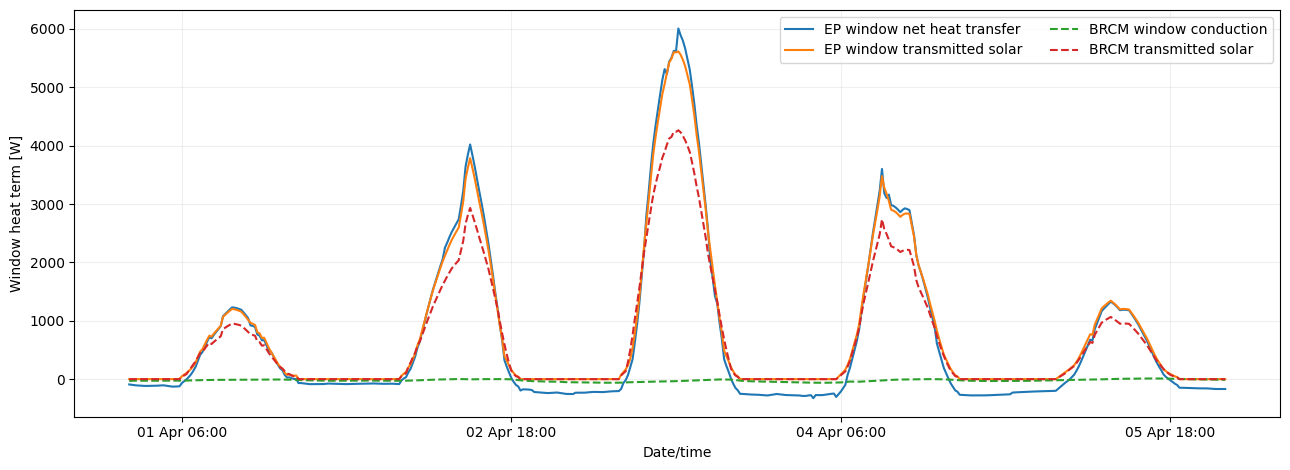

,Potential cause,Evidence,Magnitude / correlation with error,Status
0,Initial conditions,Zone states equal at t0; EP surface temperatur...,"max surface−zone offset 6.40 K; corr(error, EP...",Likely contributor to early decay
1,Solar mapping,BRCM uses window-specific incident irradiation...,EP opaque absorbed peak 177379.3 W; corr=0.07,High-priority mismatch
2,Window conduction,BRCM U=1.000; EP glass construction U=2.674,peak |EP net|=6007.5 W; peak |BRCM conduction|...,Confirmed property mismatch
3,Transmitted solar,BRCM g=0.500; EP SHGC=0.775,"peak EP/BRCM=5614.8/4263.5 W; corr(error, diff...",Confirmed property/formulation mismatch
4,External convection,BRCM exterior h is fixed; EnergyPlus DOE-2 ext...,EP h range 1.48–1000.00 W/m²K versus BRCM 12.5,Likely contributor
5,Long-wave radiation,EnergyPlus has explicit sky/ground exchange; B...,peak net exterior long-wave 91871.6 W; corr=0.15,Likely contributor
6,Internal gains,EnergyPlus convective+radiant gains are mapped...,peak total 0.0 W,Mapped; radiant distribution simplified
7,Infiltration,No IDF infiltration/ventilation objects; BRCM ...,EP outdoor-air transfer peak 0.000 W,Ruled out for this case
8,Construction properties,"Opaque layer order, areas, U, material R/thick...",area/U/C rows passing: 6/6/6 of 6; window defa...,Opaque conversion consistent; window mismatch
9,Timestep/discretisation,Both use 15-minute intervals; BRCM exact ZOH c...,480 aligned finite samples; identical zone t0,Pass


Most likely causes (no tuning applied):
1. Missing opaque-surface absorbed solar for massless exterior elements.
2. Window conversion defaults (U=1, g=0.5, no frame) differ from the EnergyPlus window data.
3. Fixed exterior coefficients and omitted explicit sky/ground long-wave exchange; non-equivalent initial envelope temperatures also affect early decay.


,BRCM state,source,resistance fraction f,initial temperature [°C]
0,x_Z0001,zone air,0.0,6.871468
1,x_B0005_L1_s1_ADBZ0001,Zn001:Flr001: inside→outside resistance interp...,0.5,7.228406


,Case,Change,RMSE [K],CVRMSE [%],NMBE [%],MAE [K],Max error [K],Improvement vs baseline [K RMSE]
0,A — Baseline current BRCM,None,2.838,26.680,-21.377,2.326,5.159,0.000
1,B — Correct window assembly U/g,Input/equivalence: U and SHGC including frame/...,2.303,21.650,-16.371,1.880,4.383,0.535
2,C — B + opaque absorbed solar,Input/equivalence: surface-specific absorbed o...,1.820,17.111,8.912,1.245,6.608,1.018
3,D — C + resistance-weighted x0,Input/equivalence: construction states from EP...,1.901,17.872,10.346,1.312,6.749,0.937


,Parameter,Value,Unit,Source
0,Window assembly U,3.798,W/m²K,EnergyPlus EIO FenestrationAssembly
1,Window assembly SHGC,0.684,-,EnergyPlus EIO FenestrationAssembly
2,Gross window area,10.000,m²,EnergyPlus/BRCM geometry
3,Zn001:Wall001 solar absorptance,0.750,-,EnergyPlus exterior material
4,Zn001:Wall002 solar absorptance,0.750,-,EnergyPlus exterior material
5,Zn001:Wall003 solar absorptance,0.750,-,EnergyPlus exterior material
6,Zn001:Wall004 solar absorptance,0.750,-,EnergyPlus exterior material
7,Zn001:Roof001 solar absorptance,0.750,-,EnergyPlus exterior material


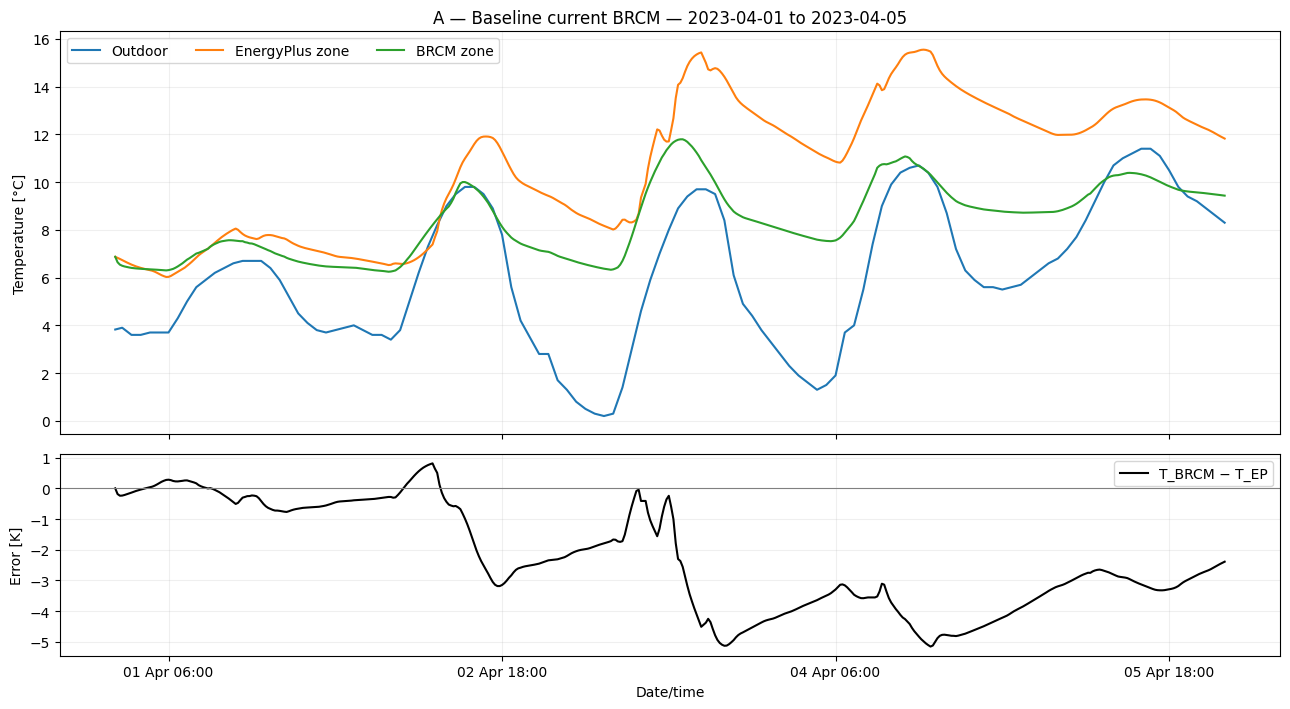

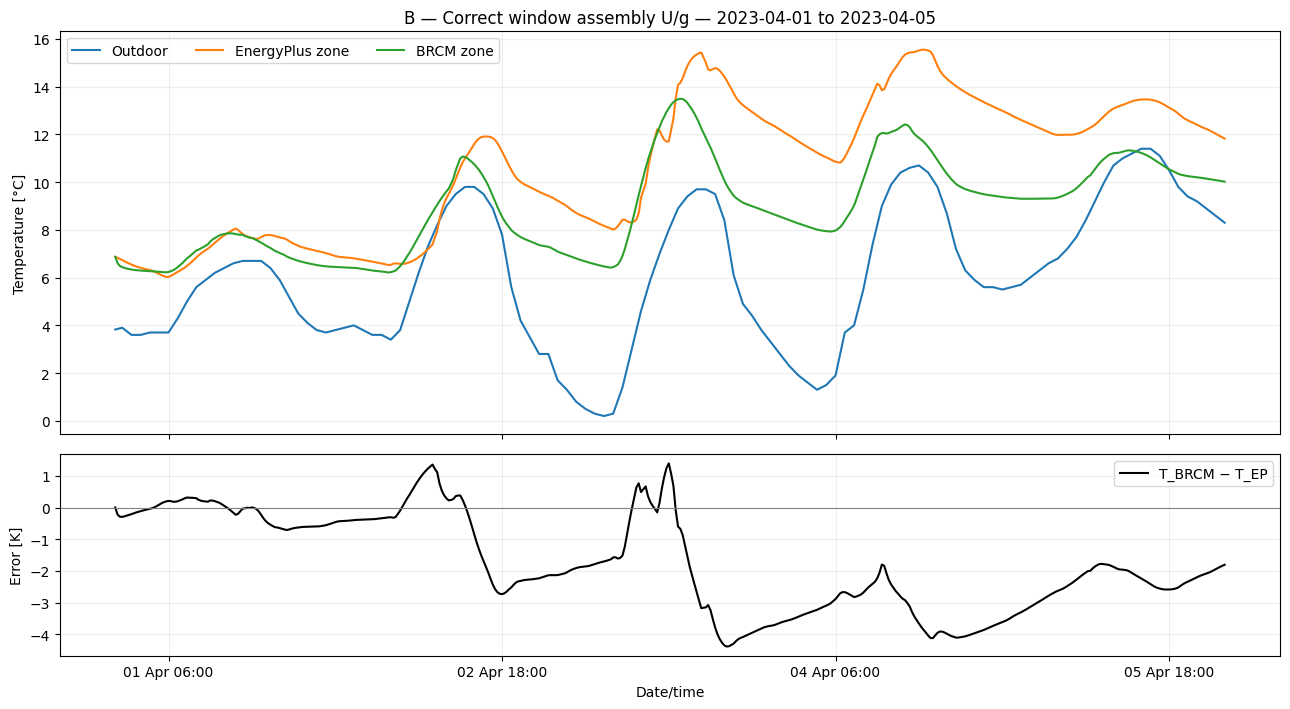

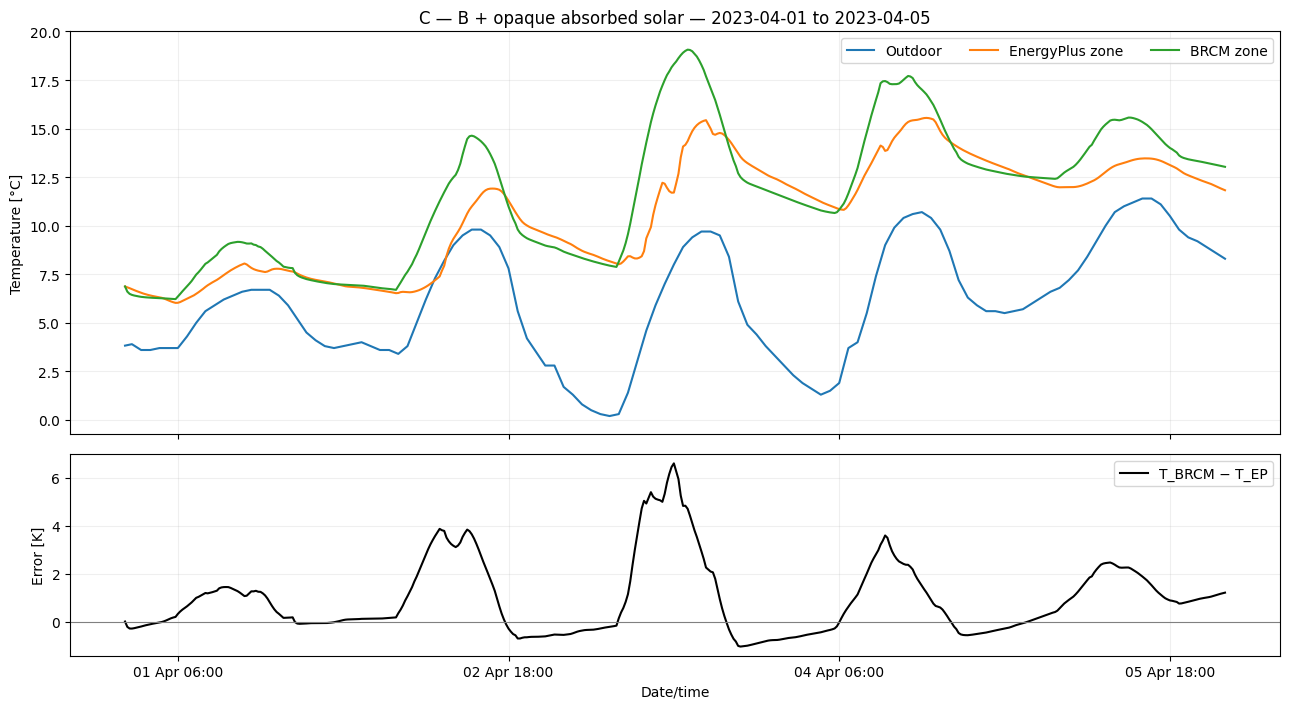

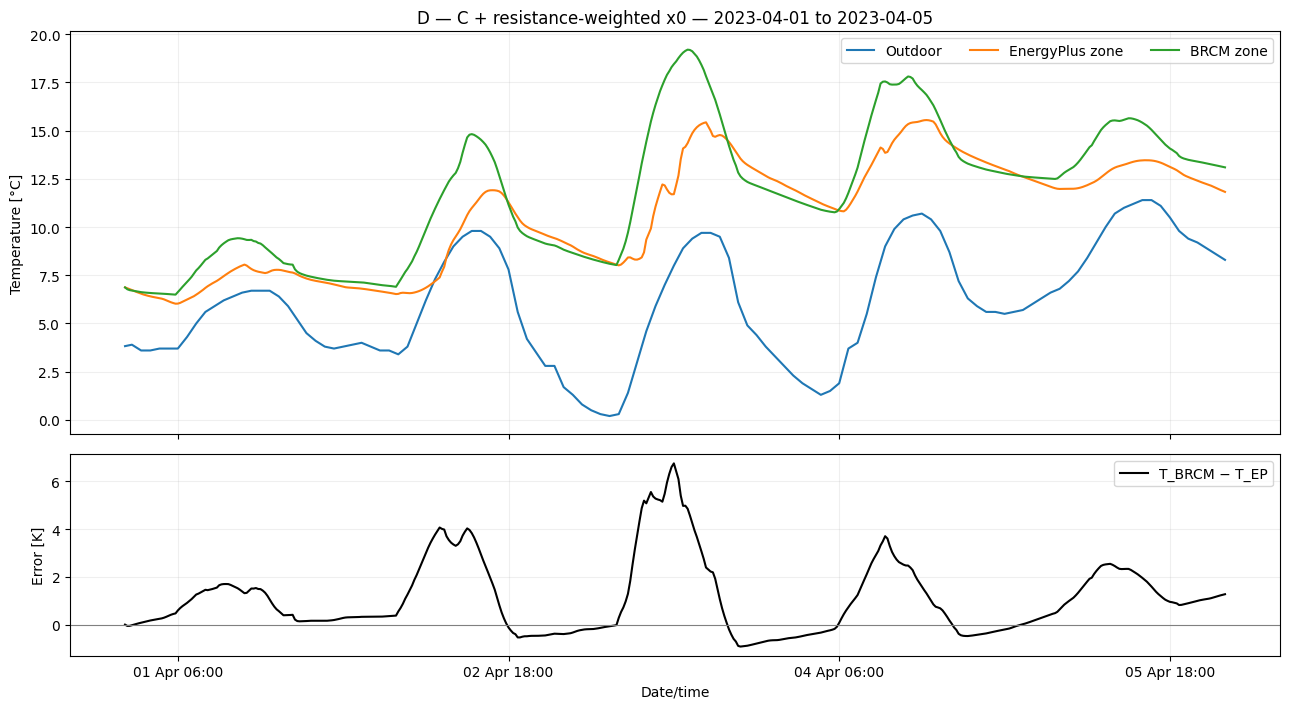

Copied notebook: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/pre_test/notebooks/BRCM_EnergyPlus_23_2_Minimal_Comparison_ablation.ipynb
Formulas: q_window,cond=U_assembly*A_gross*(T_out-T_zone); q_window,solar=SHGC_assembly*A_gross*I_window; q_abs,opaque=alpha*A_net*I_surface; q_into_RC=G*q_abs/(h_ext*A_net); T_node=T_inside+f_R*(T_outside-T_inside).
Sequential RMSE reductions [K]: [0.0, 0.535, 0.483, -0.081]
Largest incremental effect: B — Correct window assembly U/g reduction 0.535 K RMSE
Residual after all equivalence fixes: 1.901 K RMSE
Dynamic exterior convection/long-wave was not folded into A–D: it is a model-form modification, not an input correction. Residual error should be tested against that separately, with explicit labelling, before any calibration.


,Desired EnergyPlus variable,Status,Exact matched CSV column name(s)
0,Surface Window Transmitted Solar Radiation Rate,FOUND,ZN001:WALL001:WIN001:Surface Window Transmitte...
1,Surface Window Net Heat Transfer Rate,FOUND,ZN001:WALL001:WIN001:Surface Window Net Heat T...
2,Surface Window Heat Gain Rate,FOUND,ZN001:WALL001:WIN001:Surface Window Heat Gain ...
3,Surface Window Heat Loss Rate,FOUND,ZN001:WALL001:WIN001:Surface Window Heat Loss ...
4,Surface Window Frame Heat Gain Rate,FOUND,ZN001:WALL001:WIN001:Surface Window Frame Heat...
5,Surface Window Frame Heat Loss Rate,FOUND,ZN001:WALL001:WIN001:Surface Window Frame Heat...
6,Surface Outside Face Incident Solar Radiation ...,FOUND,ZN001:WALL001:Surface Outside Face Incident So...
7,Surface Outside Face Solar Radiation Heat Gain...,FOUND,ZN001:WALL001:Surface Outside Face Solar Radia...
8,Surface Outside Face Convection Heat Transfer ...,FOUND,ZN001:WALL001:Surface Outside Face Convection ...
9,Surface Outside Face Convection Heat Gain Rate,FOUND,ZN001:WALL001:Surface Outside Face Convection ...


FOUND: Surface Window Transmitted Solar Radiation Rate
ZN001:WALL001:WIN001:Surface Window Transmitted Solar Radiation Rate [W](TimeStep)
FOUND: Surface Window Net Heat Transfer Rate
ZN001:WALL001:WIN001:Surface Window Net Heat Transfer Rate [W](TimeStep)
FOUND: Surface Window Heat Gain Rate
ZN001:WALL001:WIN001:Surface Window Heat Gain Rate [W](TimeStep)
FOUND: Surface Window Heat Loss Rate
ZN001:WALL001:WIN001:Surface Window Heat Loss Rate [W](TimeStep)
FOUND: Surface Window Frame Heat Gain Rate
ZN001:WALL001:WIN001:Surface Window Frame Heat Gain Rate [W](TimeStep)
FOUND: Surface Window Frame Heat Loss Rate
ZN001:WALL001:WIN001:Surface Window Frame Heat Loss Rate [W](TimeStep)
FOUND: Surface Outside Face Incident Solar Radiation Rate per Area
ZN001:WALL001:Surface Outside Face Incident Solar Radiation Rate per Area [W/m2](TimeStep)
ZN001:WALL002:Surface Outside Face Incident Solar Radiation Rate per Area [W/m2](TimeStep)
ZN001:WALL003:Surface Outside Face Incident Solar Radiation Rat

,Case,Window overwrite,Opaque solar overwrite,Dynamic convection,Long-wave overwrite,RMSE [K],NMBE [%],MAE [K],Max error [K],Improvement vs current 1.901 K [RMSE]
0,E0 — current equivalence-fixed model,BRCM,BRCM sol-air,fixed BRCM,none,1.901,10.346,1.312,6.749,0.000
1,E1 — exact EP window transmitted solar,EP transmitted only,BRCM sol-air,fixed BRCM,none,1.680,7.501,1.182,6.305,0.221
2,E2 — exact EP complete window net,EP net (no solar double count),BRCM sol-air,fixed BRCM,none,1.954,10.862,1.336,6.948,-0.053
3,E3 — E2 + exact EP opaque solar,EP net,EP reported gain,fixed BRCM,none,155.071,1255.711,133.584,276.688,-153.170
4,E4 — E3 + exact EP exterior convection,EP net,EP reported gain,EP reported pure forcing,none,137.948,1111.653,118.258,229.308,-136.047
5,E5 — E3 + exact EP exterior long-wave,EP net,EP reported gain,fixed BRCM,EP net radiation,76.595,573.836,61.920,199.630,-74.694
6,E6 — all EP-forced exterior/window terms,EP net,EP reported gain,EP reported pure forcing,EP net radiation,2.076,-9.767,1.698,4.402,-0.174


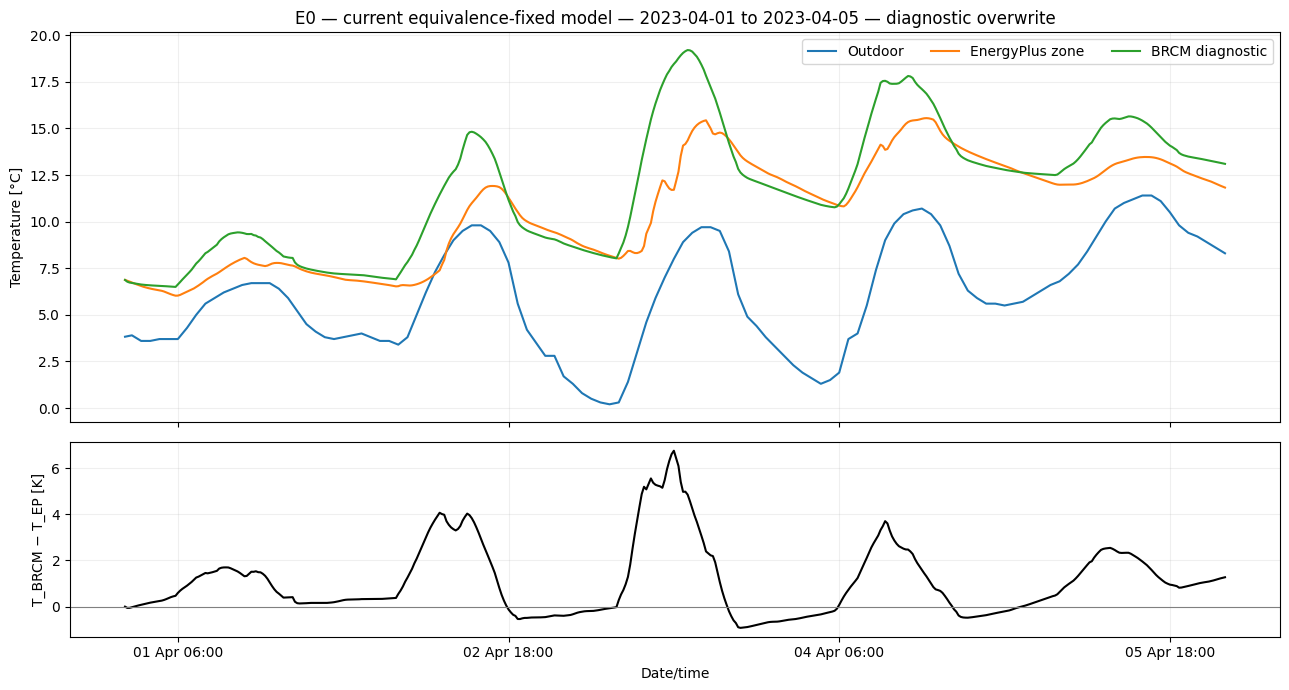

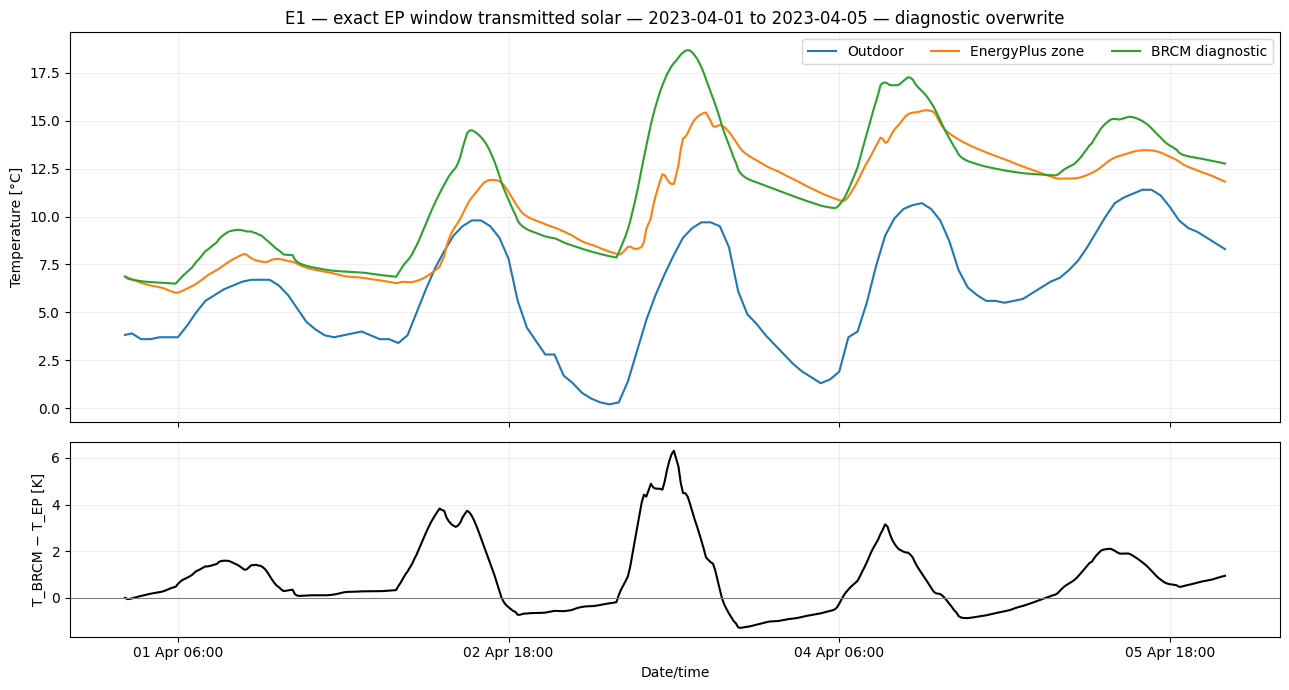

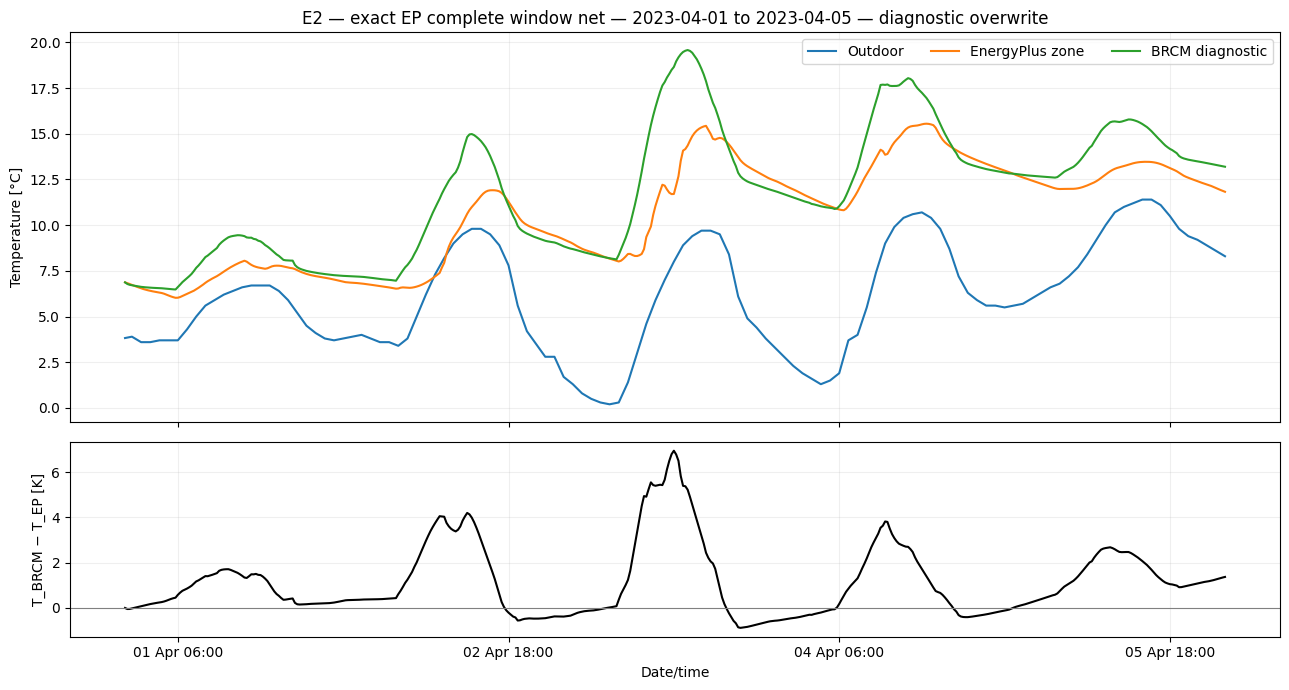

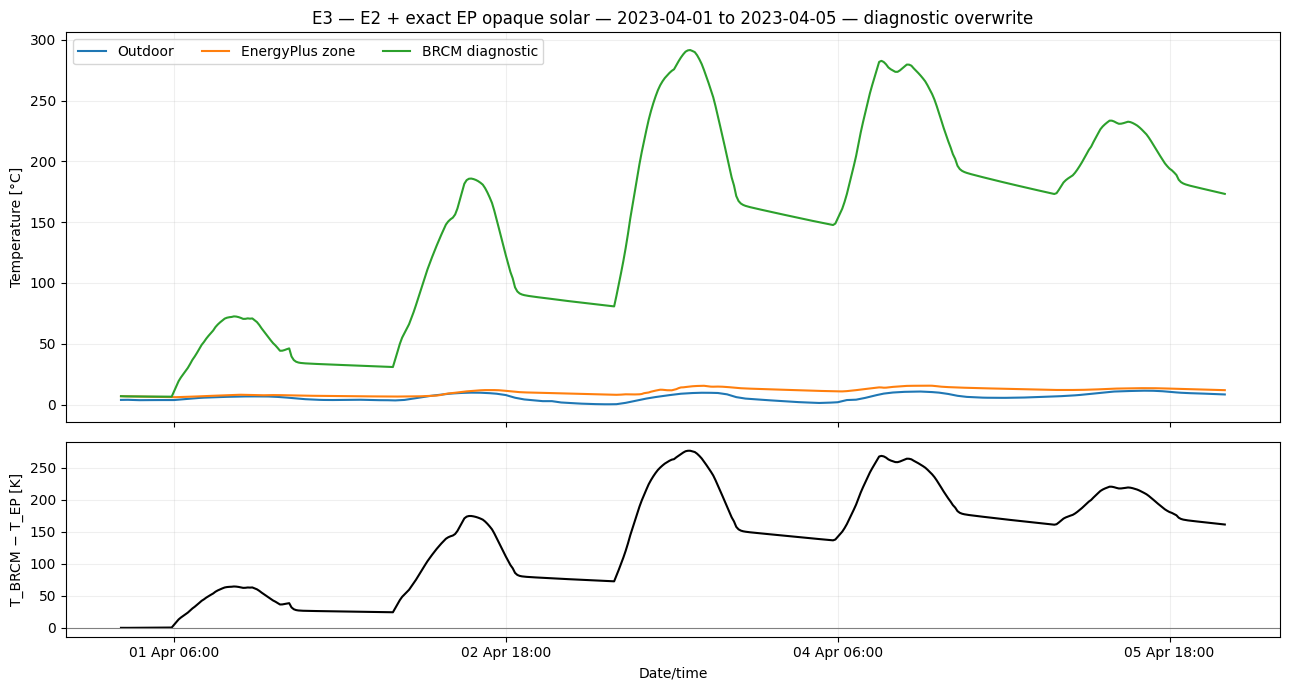

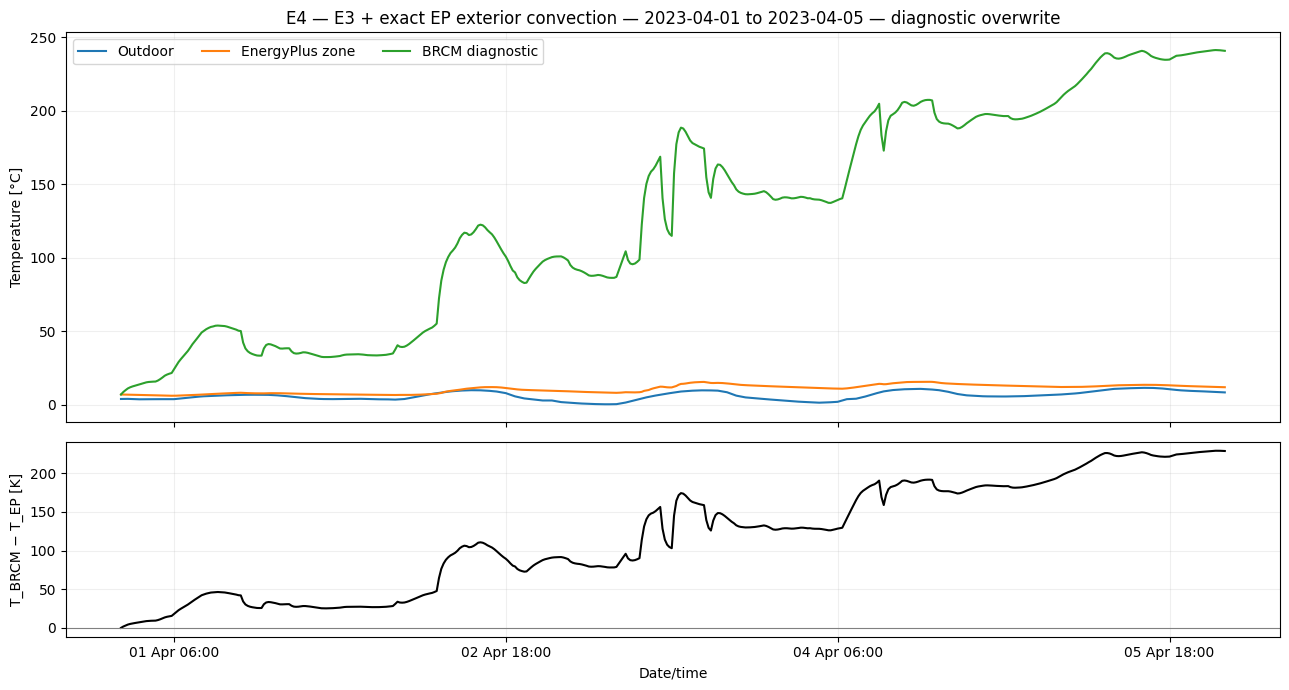

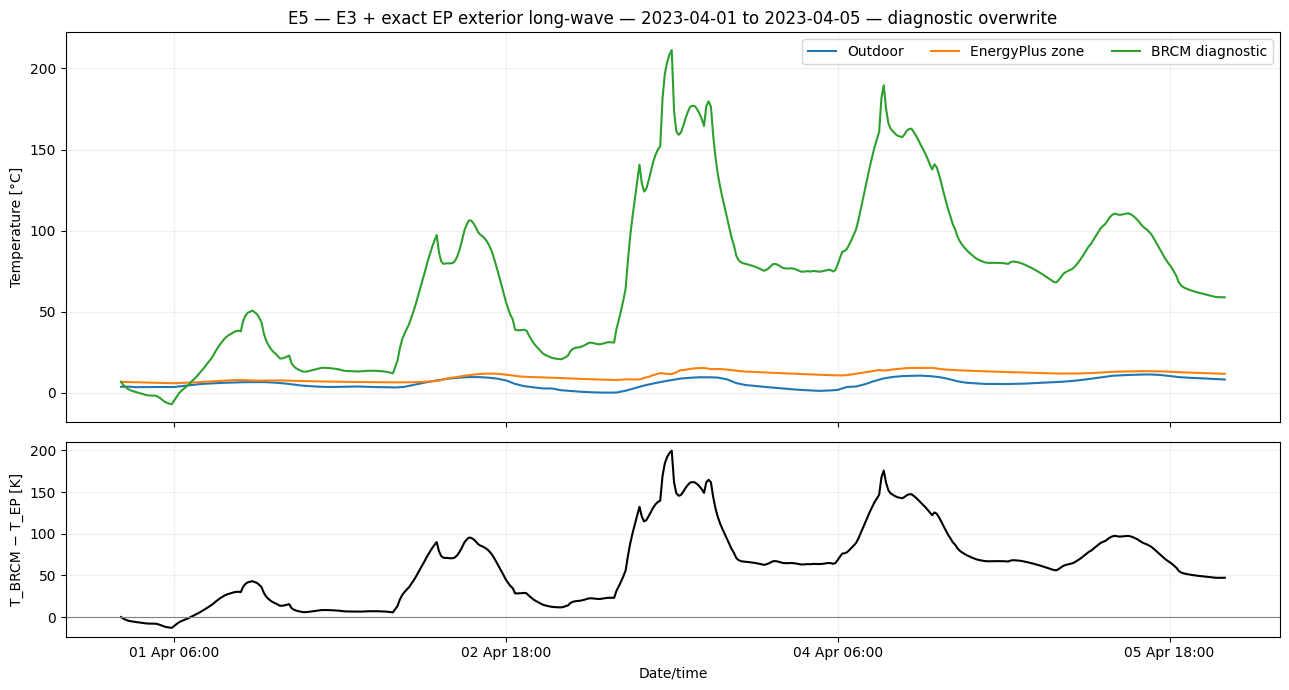

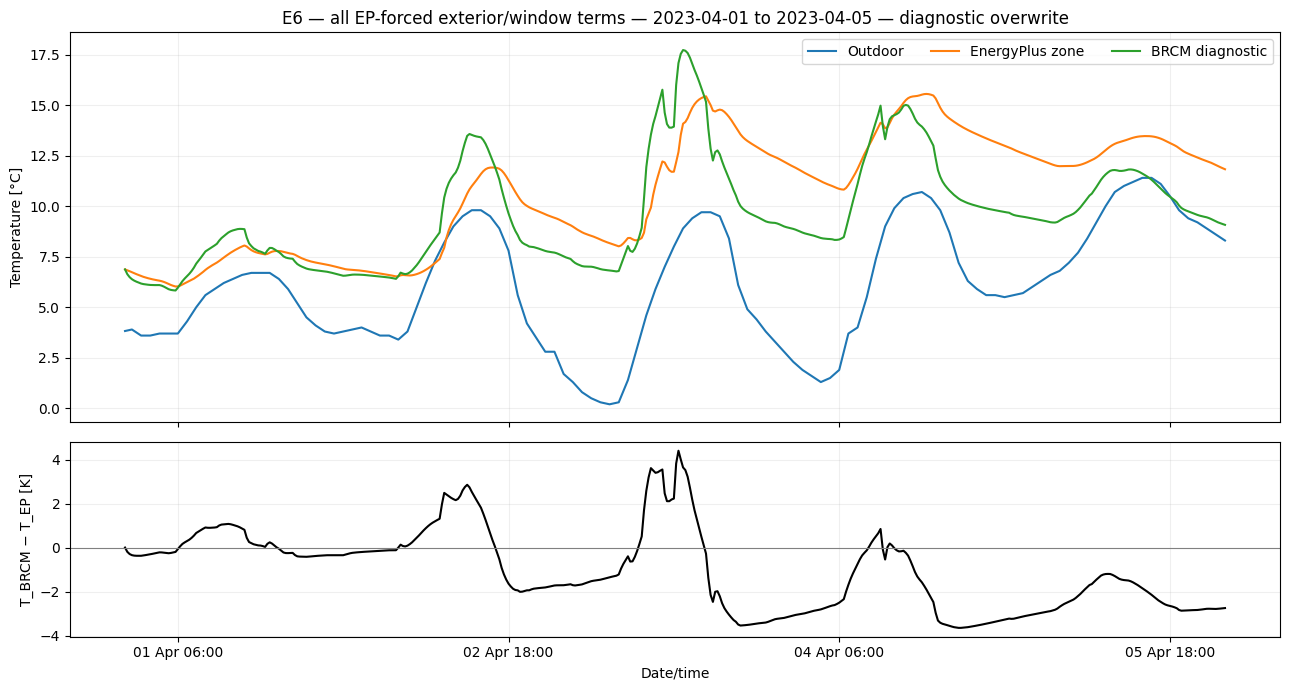

EnergyPlus was rerun because valid requested variables were absent from the prior CSV.
Unavailable in the EnergyPlus 23.2 RDD and still MISSING: Surface Outside Face Thermal Radiation to Sky Heat Transfer Rate.
Largest diagnostic improvement: E1 — exact EP window transmitted solar 0.221 K RMSE
Residual RMSE after all diagnostic overwrites (E6): 2.076 K
E2–E6 are diagnostic EP-forced models, not independent predictive BRCM simulations.


In [8]:
def column_in(frame, variable, key=None):
    matches = [column for column in frame if variable.casefold() in column.casefold() and (key is None or f'{key}:{variable}'.casefold() in column.casefold())]
    if len(matches) != 1: raise KeyError(f'Expected one column for {key!r}/{variable!r}; found {matches}')
    return matches[0]

def prepare_weather_idf(path, start_date, end_date):
    shutil.copy2(IDF, path)
    md_IDFdt(path, start_date=start_date, end_date=end_date)
    lines = path.read_text(encoding='utf-8').splitlines(keepends=True)
    for object_name, changes in [('RunPeriod,', {3: str(pd.Timestamp(start_date).year), 6: str(pd.Timestamp(end_date).year)}), ('SimulationControl,', {3: 'No', 4: 'Yes'})]:
        start = next(i for i, line in enumerate(lines) if line.strip().casefold().startswith(object_name.casefold()))
        fields, index = [], start + 1
        while index < len(lines):
            fields.append(index)
            if ';' in lines[index]: break
            index += 1
        for position, value in changes.items():
            row = fields[position]
            delimiter = ',' if ',' in lines[row] else ';'
            suffix = lines[row][lines[row].find(delimiter):]
            indent = lines[row][:len(lines[row]) - len(lines[row].lstrip())]
            lines[row] = f'{indent}{value}{suffix}'
    path.write_text(''.join(lines), encoding='utf-8')
    window_data = (ENERGYPLUS.parent / 'DataSets' / 'Window5DataFile.dat').resolve()
    text = path.read_text(encoding='utf-8').replace(r'..\datasets\Window5DataFile.dat', str(window_data))
    requests = '\n'.join([
        'Output:Variable,*,Site Outdoor Air Drybulb Temperature,timestep;',
        'Output:Variable,*,Site Ground Temperature,timestep;',
        'Output:Variable,*,Site Surface Ground Temperature,timestep;',
        'Output:Variable,*,Site Deep Ground Temperature,timestep;',
        'Output:Variable,*,Site Simple Factor Model Ground Temperature,timestep;',
        'Output:Variable,*,Site Direct Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Site Diffuse Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Zone Mean Air Temperature,timestep;',
        'Output:Variable,*,Surface Inside Face Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Convection Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Convection Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Outside Face Outdoor Air Drybulb Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Net Thermal Radiation Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Rate,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Air Heat Transfer Rate,timestep;',
        'Output:Variable,*,Site Sky Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Incident Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Surface Outside Face Solar Radiation Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Window Transmitted Solar Radiation Rate,timestep;',
        'Output:Variable,*,Surface Window Net Heat Transfer Rate,timestep;',
        'Output:Variable,*,Surface Window Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Window Heat Loss Rate,timestep;',
        'Output:Variable,*,Surface Window Frame Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Window Frame Heat Loss Rate,timestep;',
        'Output:Variable,*,Zone Windows Total Transmitted Solar Radiation Rate,timestep;',
        'Output:Variable,*,Zone Total Internal Convective Heating Rate,timestep;',
        'Output:Variable,*,Zone Total Internal Radiant Heating Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Surface Convection Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Internal Convective Heat Gain Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Outdoor Air Transfer Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Interzone Air Transfer Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance System Air Transfer Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Air Energy Storage Rate,timestep;',
    ])
    path.write_text(text + '\n' + requests + '\n', encoding='utf-8')
    IDFout(path, ['CSV', 'MTR', 'Tabular', 'RDD'])

def interval_end_datetimes(values, year):
    result = []
    for raw in values:
        month, day, hour, minute, second = map(int, re.fullmatch(r'\s*(\d{1,2})/(\d{1,2})\s+(\d{1,2}):(\d{2}):(\d{2})\s*', str(raw)).groups())
        result.append(pd.Timestamp(year=year, month=month, day=day) + pd.Timedelta(hours=hour, minutes=minute, seconds=second))
    return pd.DatetimeIndex(result)

seasonal_results, metric_rows = {}, []
for season, (start_date, end_date) in PERIODS.items():
    run_root = WORK / 'seasonal' / season.casefold()
    run_root.mkdir(parents=True, exist_ok=True)
    seasonal_idf = run_root / IDF.name
    prepare_weather_idf(seasonal_idf, start_date, end_date)
    output_dir = Path(run_IDF(seasonal_idf, EPW, ENERGYPLUS))
    frame = pd.read_csv(output_dir / 'eplusout.csv')
    time_column = next(column for column in frame if 'date/time' in column.casefold().replace(' ', ''))
    times = interval_end_datetimes(frame[time_column], pd.Timestamp(start_date).year)
    forcing = {'v_Tamb': frame[column_in(frame, 'Site Outdoor Air Drybulb Temperature')].to_numpy(float)}
    for element in window_elements:
        parent = element.description.split(':', 1)[1]
        ep_window = ep_window_by_parent[parent.casefold()]
        forcing[f'v_solGlobFac_{element.identifier}'] = frame[column_in(frame, 'Surface Outside Face Incident Solar Radiation Rate per Area', ep_window.name)].to_numpy(float)
    for zone in thermal_data.zones:
        conv = frame[column_in(frame, 'Zone Total Internal Convective Heating Rate', zone.description)].to_numpy(float)
        rad = frame[column_in(frame, 'Zone Total Internal Radiant Heating Rate', zone.description)].to_numpy(float)
        forcing[f'v_IG_{zone.identifier}'] = (conv + rad) / thermal_data.eval_str(zone.area)
    V_season = np.vstack([forcing[name][1:] for name in building_model.identifiers.v])
    U_season = np.zeros((len(building_model.identifiers.u), len(frame) - 1))
    zone = thermal_data.zones[0]
    ep_zone = frame[column_in(frame, 'Zone Mean Air Temperature', zone.description)].to_numpy(float)
    x0_season = np.full((len(building_model.identifiers.x), 1), ep_zone[0])
    run = brcm.simulate_building_model(building_model, x0_season, U_season, V_season)
    rc_zone = run.X_full[x_index[f'x_{zone.identifier}']]
    outdoor = forcing['v_Tamb']
    direct = frame[column_in(frame, 'Site Direct Solar Radiation Rate per Area')].to_numpy(float)
    diffuse = frame[column_in(frame, 'Site Diffuse Solar Radiation Rate per Area')].to_numpy(float)
    error = rc_zone - ep_zone
    metric_rows.append([season, error.mean(), np.sqrt(np.mean(error**2)), np.mean(np.abs(error)), np.max(np.abs(error))])
    seasonal_results[season] = dict(times=times, ep=ep_zone, rc=rc_zone, outdoor=outdoor, direct=direct, diffuse=diffuse, start=start_date, end=end_date, zone=zone.description, frame=frame, output_dir=output_dir, x0=x0_season, run=run)

display(pd.DataFrame(metric_rows, columns=['Season', 'Mean bias [K]', 'RMSE [K]', 'MAE [K]', 'Max |error| [K]']).round(3))
for season, result in seasonal_results.items():
    fig, left = plt.subplots(figsize=(12, 4.8))
    left.plot(result['times'], result['outdoor'], color='tab:blue', alpha=0.75, label='Outdoor dry-bulb')
    left.plot(result['times'], result['ep'], color='tab:red', linewidth=1.7, label='EnergyPlus zone air')
    left.plot(result['times'], result['rc'], color='tab:green', linewidth=1.7, label='BRCM zone air')
    left.set_ylabel('Temperature [°C]')
    left.set_xlabel('Date/time')
    left.xaxis.set_major_locator(mdates.HourLocator(interval=36))
    left.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    left.grid(alpha=0.2)
    right = left.twinx()
    right.plot(result['times'], result['direct'], color='tab:orange', alpha=0.55, label='Direct solar')
    right.plot(result['times'], result['diffuse'], color='tab:purple', alpha=0.55, label='Diffuse solar')
    right.set_ylabel('Solar irradiance [W/m²]')
    handles_left, labels_left = left.get_legend_handles_labels()
    handles_right, labels_right = right.get_legend_handles_labels()
    left.legend(handles_left + handles_right, labels_left + labels_right, loc='upper left', ncol=2)
    left.set_title(f"{result['zone']} — {result['start']} to {result['end']} — independent open-loop comparison")
    fig.autofmt_xdate(rotation=0); fig.tight_layout(); plt.show()

# --- Attribution diagnostics: April worked example, parameters unchanged ---
diagnostic = seasonal_results['April']
frame, times = diagnostic['frame'], diagnostic['times']
ep_zone, rc_zone = diagnostic['ep'], diagnostic['rc']
error = rc_zone - ep_zone

def matching_columns(text):
    return [column for column in frame if text.casefold() in column.casefold()]

def summed_columns(text):
    columns = matching_columns(text)
    return np.zeros(len(frame)) if not columns else frame[columns].to_numpy(float).sum(axis=1)

def safe_correlation(left, right):
    left, right = np.asarray(left, float), np.asarray(right, float)
    return np.nan if np.std(left) == 0 or np.std(right) == 0 else float(np.corrcoef(left, right)[0, 1])

# 1. Initial conditions: zone equality does not imply equivalent envelope states.
inside_temperature_columns = matching_columns('Surface Inside Face Temperature')
outside_temperature_columns = matching_columns('Surface Outside Face Temperature')
surface_t0 = pd.Series({column.split(' [C]', 1)[0]: frame[column].iloc[0] for column in inside_temperature_columns + outside_temperature_columns}, name='temperature at t0 [°C]')
print('T_zone_EP(t0):', ep_zone[0])
print('T_zone_BRCM(t0):', rc_zone[0])
print('min/max BRCM x0:', float(diagnostic['x0'].min()), float(diagnostic['x0'].max()))
display(surface_t0.to_frame())
initial_surface_span = float(surface_t0.max() - surface_t0.min())
initial_state_surface_offset = float(np.max(np.abs(surface_t0.to_numpy(float) - ep_zone[0])))

# 2. Exterior coefficients: EnergyPlus is dynamic DOE-2 outside convection plus explicit long-wave exchange.
h_conv_columns = matching_columns('Surface Outside Face Convection Heat Transfer Coefficient')
h_sky_columns = matching_columns('Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient')
h_ground_columns = matching_columns('Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient')
net_lw = summed_columns('Surface Outside Face Net Thermal Radiation Heat Gain Rate')
boundary_rows = []
ambient_elements = [element for element in thermal_data.building_elements if 'AMB' in (element.adjacent_A, element.adjacent_B)]
for boundary, element in zip(thermal_model.boundary_conditions['ambient'], ambient_elements):
    construction = next(item for item in thermal_data.constructions if item.identifier == element.construction_identifier)
    fixed_h = thermal_data.eval_str(construction.conv_coeff_adjacent_A if element.adjacent_A == 'AMB' else construction.conv_coeff_adjacent_B)
    ep_name = element.description.split(':', 1)[1]
    h_column = next((column for column in h_conv_columns if column.casefold().startswith(ep_name.casefold() + ':')), None)
    sky_column = next((column for column in h_sky_columns if column.casefold().startswith(ep_name.casefold() + ':')), None)
    ground_column = next((column for column in h_ground_columns if column.casefold().startswith(ep_name.casefold() + ':')), None)
    boundary_rows.append([ep_name, fixed_h, boundary.value, np.nan if h_column is None else frame[h_column].min(), np.nan if h_column is None else frame[h_column].max(), np.nan if sky_column is None else frame[sky_column].mean(), np.nan if ground_column is None else frame[ground_column].mean()])
boundary_comparison = pd.DataFrame(boundary_rows, columns=['Surface', 'BRCM fixed exterior h [W/m²K]', 'BRCM total path G [W/K]', 'EP h_conv min', 'EP h_conv max', 'EP h_sky mean', 'EP h_ground mean'])
display(boundary_comparison.round(3))

# 3–4. Solar and windows: BRCM uses window-specific incident irradiation, never raw DNI as facade irradiation.
window_element = window_elements[0]
parent_name = window_element.description.split(':', 1)[1]
ep_window = ep_window_by_parent[parent_name.casefold()]
incident_column = column_in(frame, 'Surface Outside Face Incident Solar Radiation Rate per Area', ep_window.name)
ep_window_transmitted = frame[column_in(frame, 'Surface Window Transmitted Solar Radiation Rate', ep_window.name)].to_numpy(float)
ep_window_net = frame[column_in(frame, 'Surface Window Net Heat Transfer Rate', ep_window.name)].to_numpy(float)
ep_zone_window_transmitted = frame[column_in(frame, 'Zone Windows Total Transmitted Solar Radiation Rate', thermal_data.zones[0].description)].to_numpy(float)
opaque_solar_columns = [column for column in matching_columns('Surface Outside Face Solar Radiation Heat Gain Rate') if ep_window.name.casefold() not in column.casefold()]
ep_opaque_absorbed = np.zeros(len(frame)) if not opaque_solar_columns else frame[opaque_solar_columns].to_numpy(float).sum(axis=1)
window = thermal_data.windows[thermal_data.get_window_idx_from_identifier(window_element.window_identifier)]
window_area = thermal_data.eval_str(window.glass_area) + thermal_data.eval_str(window.frame_area)
brcm_window_u = thermal_data.eval_str(window.U_value)
brcm_window_shgc = thermal_data.eval_str(window.SHGC)
incident_window = frame[incident_column].to_numpy(float)
brcm_window_conduction = brcm_window_u * window_area * (diagnostic['outdoor'] - rc_zone)
brcm_window_solar = window_area * brcm_window_shgc * incident_window
eio_lines = (diagnostic['output_dir'] / 'eplusout.eio').read_text(errors='replace').splitlines()
window_construction_line = next(line for line in eio_lines if line.lstrip().startswith('WindowConstruction,DOUBLECLEAR'))
window_parts = [part.strip() for part in window_construction_line.split(',')]
ep_window_u, ep_window_shgc = float(window_parts[5]), float(window_parts[8])
window_comparison = pd.DataFrame([
    ['BRCM converted', window_area, brcm_window_u, brcm_window_shgc, thermal_data.eval_str(window.frame_area)],
    ['EnergyPlus glass construction', 10.0, ep_window_u, ep_window_shgc, 'frame/divider modelled separately'],
], columns=['Model', 'window area [m²]', 'U-value [W/m²K]', 'SHGC/g-value', 'frame/divider'])
display(window_comparison)

# 5–6. Internal gains and outdoor-air transfer.
ep_internal_convective = frame[column_in(frame, 'Zone Total Internal Convective Heating Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_internal_radiant = frame[column_in(frame, 'Zone Total Internal Radiant Heating Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_outdoor_air = frame[column_in(frame, 'Zone Air Heat Balance Outdoor Air Transfer Rate', thermal_data.zones[0].description)].to_numpy(float)
print('Internal gains peak convective/radiant [W]:', ep_internal_convective.max(), ep_internal_radiant.max())
print('Outdoor-air transfer min/max [W]:', ep_outdoor_air.min(), ep_outdoor_air.max(), '(BRCM infiltration configured as 0 ACH)')

# 7. Construction, material, area, capacitance, and boundary audit.
construction_by_id = {item.identifier: item for item in thermal_data.constructions}
material_by_id = {item.identifier: item for item in thermal_data.materials}
ep_surface_info = {}
for line in eio_lines:
    if line.startswith('HeatTransfer Surface,'):
        parts = [part.strip() for part in line.split(',')]
        try:
            ep_surface_info[parts[1].casefold()] = {'u': float(parts[6]), 'area': float(parts[10])}
        except ValueError:
            pass  # Window rows can report N/A here; windows are audited separately above.
construction_rows = []
for element in thermal_data.building_elements:
    construction = construction_by_id[element.construction_identifier]
    layer_text, total_r, ep_capacitance = [], 0.0, 0.0
    for material_id, thickness_raw in zip(construction.material_identifiers, construction.thickness):
        material = material_by_id[material_id]
        thickness = thermal_data.eval_str(thickness_raw)
        if material.R_value:
            resistance = thermal_data.eval_str(material.R_value)
            density = specific_heat = np.nan
        else:
            resistance = thickness * thermal_data.eval_str(material.specific_thermal_resistance)
            density = thermal_data.eval_str(material.density); specific_heat = thermal_data.eval_str(material.specific_heat_capacity)
            ep_capacitance += thermal_data.eval_str(element.area) * thickness * density * specific_heat
        total_r += resistance
        layer_text.append(f'{material.description}: t={thickness:g} m, R={resistance:g}, rho={density:g}, cp={specific_heat:g}')
    state_prefix = f'x_{element.identifier}_'
    brcm_capacitance = sum(thermal_model.Xcap[i, i] for i, name in enumerate(thermal_model.state_identifiers) if name.startswith(state_prefix))
    boundary_type = 'ambient' if 'AMB' in (element.adjacent_A, element.adjacent_B) else ('adiabatic' if 'ADB' in (element.adjacent_A, element.adjacent_B) else ('ground' if 'GND' in (element.adjacent_A, element.adjacent_B) else 'interzone/user'))
    surface_name = element.description.split(':', 1)[-1]
    ep_info = ep_surface_info[surface_name.casefold()]
    brcm_area = thermal_data.eval_str(element.area); brcm_u = np.nan if total_r == 0 else 1 / total_r
    construction_rows.append([surface_name, ep_info['area'], brcm_area, np.isclose(ep_info['area'], brcm_area, atol=0.02), construction.description, ep_info['u'], brcm_u, np.isclose(ep_info['u'], brcm_u, atol=0.001), ' | '.join(layer_text), ep_capacitance, brcm_capacitance, boundary_type, np.isclose(ep_capacitance, brcm_capacitance)])
construction_audit = pd.DataFrame(construction_rows, columns=['Surface', 'EP area [m²]', 'BRCM area [m²]', 'area match', 'construction', 'EP layer U [W/m²K]', 'BRCM layer U [W/m²K]', 'U match', 'layers: thickness/R/density/cp', 'derived EP material C [J/K]', 'BRCM C [J/K]', 'boundary', 'capacitance match'])
display(construction_audit)

# 8–9. Heat-balance timing and aligned attribution plots.
ep_surface_convection = frame[column_in(frame, 'Zone Air Heat Balance Surface Convection Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_hb_internal = frame[column_in(frame, 'Zone Air Heat Balance Internal Convective Heat Gain Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_storage = frame[column_in(frame, 'Zone Air Heat Balance Air Energy Storage Rate', thermal_data.zones[0].description)].to_numpy(float)
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
axes[0].plot(times, diagnostic['outdoor'], label='Outdoor'); axes[0].plot(times, ep_zone, label='EnergyPlus zone'); axes[0].plot(times, rc_zone, label='BRCM zone')
axes[0].set_ylabel('Temperature [°C]'); axes[0].legend(ncol=3); axes[0].grid(alpha=0.2)
axes[1].plot(times, diagnostic['direct'], label='Direct site solar'); axes[1].plot(times, diagnostic['diffuse'], label='Diffuse site solar'); axes[1].plot(times, incident_window, label='Window incident solar'); axes[1].plot(times, ep_window_transmitted, label='EP window transmitted [W]'); axes[1].plot(times, ep_internal_convective + ep_internal_radiant, label='Internal gains [W]')
axes[1].set_ylabel('Irradiance [W/m²] / heat [W]'); axes[1].legend(ncol=3, fontsize=8); axes[1].grid(alpha=0.2)
axes[2].plot(times, error, color='black', label='T_BRCM − T_EP'); axes[2].axhline(0, color='grey', linewidth=0.8)
axes[2].set_ylabel('Error [K]'); axes[2].legend(); axes[2].grid(alpha=0.2); axes[2].set_xlabel('Date/time')
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=36)); axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
fig.suptitle(f"{diagnostic['zone']} — {diagnostic['start']} to {diagnostic['end']} — forcing/error attribution"); fig.tight_layout(); plt.show()

fig, heat_axis = plt.subplots(figsize=(13, 4.8))
heat_axis.plot(times, ep_surface_convection, label='EP surface convection to zone'); heat_axis.plot(times, ep_hb_internal, label='EP internal convective'); heat_axis.plot(times, ep_outdoor_air, label='EP outdoor-air transfer'); heat_axis.plot(times, ep_storage, label='EP air storage')
heat_axis.set_ylabel('Heat-balance rate [W]'); heat_axis.set_xlabel('Date/time'); heat_axis.grid(alpha=0.2)
error_axis = heat_axis.twinx(); error_axis.plot(times, error, color='black', linewidth=1.4, label='Temperature error'); error_axis.set_ylabel('T_BRCM − T_EP [K]')
handles1, labels1 = heat_axis.get_legend_handles_labels(); handles2, labels2 = error_axis.get_legend_handles_labels(); heat_axis.legend(handles1 + handles2, labels1 + labels2, ncol=3, fontsize=8)
heat_axis.xaxis.set_major_locator(mdates.HourLocator(interval=36)); heat_axis.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()

fig, window_axis = plt.subplots(figsize=(13, 4.8))
window_axis.plot(times, ep_window_net, label='EP window net heat transfer'); window_axis.plot(times, ep_window_transmitted, label='EP window transmitted solar'); window_axis.plot(times, brcm_window_conduction, '--', label='BRCM window conduction'); window_axis.plot(times, brcm_window_solar, '--', label='BRCM transmitted solar')
window_axis.set_ylabel('Window heat term [W]'); window_axis.set_xlabel('Date/time'); window_axis.grid(alpha=0.2); window_axis.legend(ncol=2)
window_axis.xaxis.set_major_locator(mdates.HourLocator(interval=36)); window_axis.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()

# 10. Evidence summary and ranked causes.
summary_rows = [
    ['Initial conditions', f'Zone states equal at t0; EP surface temperatures are not uniform (span {initial_surface_span:.2f} K)', f'max surface−zone offset {initial_state_surface_offset:.2f} K; corr(error, EP storage)={safe_correlation(error, ep_storage):.2f}', 'Likely contributor to early decay'],
    ['Solar mapping', 'BRCM uses window-specific incident irradiation; raw DNI/DHI are plotted only. Opaque massless surfaces receive no BRCM solar.', f'EP opaque absorbed peak {np.max(np.abs(ep_opaque_absorbed)):.1f} W; corr={safe_correlation(error, ep_opaque_absorbed):.2f}', 'High-priority mismatch'],
    ['Window conduction', f'BRCM U={brcm_window_u:.3f}; EP glass construction U={ep_window_u:.3f}', f'peak |EP net|={np.max(np.abs(ep_window_net)):.1f} W; peak |BRCM conduction|={np.max(np.abs(brcm_window_conduction)):.1f} W', 'Confirmed property mismatch'],
    ['Transmitted solar', f'BRCM g={brcm_window_shgc:.3f}; EP SHGC={ep_window_shgc:.3f}', f'peak EP/BRCM={ep_window_transmitted.max():.1f}/{brcm_window_solar.max():.1f} W; corr(error, difference)={safe_correlation(error, brcm_window_solar-ep_window_transmitted):.2f}', 'Confirmed property/formulation mismatch'],
    ['External convection', 'BRCM exterior h is fixed; EnergyPlus DOE-2 exterior convection varies with weather/wind', f"EP h range {min(frame[c].min() for c in h_conv_columns):.2f}–{max(frame[c].max() for c in h_conv_columns):.2f} W/m²K versus BRCM 12.5", 'Likely contributor'],
    ['Long-wave radiation', 'EnergyPlus has explicit sky/ground exchange; BRCM has no separate sky/ground long-wave disturbance', f'peak net exterior long-wave {np.max(np.abs(net_lw)):.1f} W; corr={safe_correlation(error, net_lw):.2f}', 'Likely contributor'],
    ['Internal gains', 'EnergyPlus convective+radiant gains are mapped into InternalGains', f'peak total {np.max(ep_internal_convective+ep_internal_radiant):.1f} W', 'Mapped; radiant distribution simplified'],
    ['Infiltration', 'No IDF infiltration/ventilation objects; BRCM uses 0 ACH', f'EP outdoor-air transfer peak {np.max(np.abs(ep_outdoor_air)):.3f} W', 'Ruled out for this case'],
    ['Construction properties', 'Opaque layer order, areas, U, material R/thickness/density/cp and capacitance audited against EIO above', f"area/U/C rows passing: {construction_audit['area match'].sum()}/{construction_audit['U match'].sum()}/{construction_audit['capacitance match'].sum()} of {len(construction_audit)}; window defaults differ", 'Opaque conversion consistent; window mismatch'],
    ['Timestep/discretisation', 'Both use 15-minute intervals; BRCM exact ZOH converts hours to seconds and inputs remain W', f'{len(times)} aligned finite samples; identical zone t0', 'Pass'],
]
cause_summary = pd.DataFrame(summary_rows, columns=['Potential cause', 'Evidence', 'Magnitude / correlation with error', 'Status'])
display(cause_summary)
print('Most likely causes (no tuning applied):')
print('1. Missing opaque-surface absorbed solar for massless exterior elements.')
print('2. Window conversion defaults (U=1, g=0.5, no frame) differ from the EnergyPlus window data.')
print('3. Fixed exterior coefficients and omitted explicit sky/ground long-wave exchange; non-equivalent initial envelope temperatures also affect early decay.')

# ============================================================================
# CONTROLLED ABLATION STUDY — cumulative equivalence fixes, no calibration
# ============================================================================
ablation_frame = diagnostic['frame']
ablation_times = diagnostic['times']
ablation_ep = diagnostic['ep']
ablation_outdoor = diagnostic['outdoor']
ablation_zone = thermal_data.zones[0]
n_ablation = len(ablation_frame)

# EnergyPlus assembly values include the frame/divider contribution in a single
# lumped U/SHGC pair, which is the closest representation supported by BRCM's
# one-window U-value and g-value model.
assembly_line = next(line for line in eio_lines if line.startswith('FenestrationAssembly,DOUBLECLEAR,'))
assembly_parts = [part.strip() for part in assembly_line.split(',')]
ep_assembly_u = float(assembly_parts[4])
ep_assembly_shgc = float(assembly_parts[5])

corrected_data = copy.deepcopy(thermal_data)
for parameter in corrected_data.parameters:
    if parameter.identifier == window.U_value:
        parameter.value = str(ep_assembly_u)
    elif parameter.identifier == window.SHGC:
        parameter.value = str(ep_assembly_shgc)
corrected_hull = brcm.BuildingHull(corrected_data, thermal_model, 'hull_corrected_window', hull_file)
corrected_gains = brcm.InternalGains(corrected_data, thermal_model, 'gains_corrected_window', gains_file)
window_corrected_model = brcm.BuildingModel(thermal_model, [corrected_hull, corrected_gains])
window_corrected_model.discretize(TS_HRS)

# Exterior solar absorptance comes from the EnergyPlus outside material.
solar_absorptance_by_material = {}
for obj in conversion.normalized_model.raw_objects:
    kind = obj.object_type.casefold()
    if kind == 'material:nomass' and len(obj.values) > 4:
        solar_absorptance_by_material[obj.values[0].casefold()] = float(obj.values[4])
    elif kind == 'material' and len(obj.values) > 7:
        solar_absorptance_by_material[obj.values[0].casefold()] = float(obj.values[7])
ep_construction_by_name = {item.name.casefold(): item for item in conversion.normalized_model.constructions}

class OpaqueSolarAblation(brcm.EHFModelBaseClass):
    """Massless sol-air equivalent used only for controlled case C/D."""
    def __init__(self, data, thermal, source_file):
        super().__init__(data, thermal, 'opaque_solar_ablation', source_file)
        self.identifiers.v = []
        self.records = []
        exterior = [element for element in data.building_elements if 'AMB' in (element.adjacent_A, element.adjacent_B)]
        for boundary, element in zip(thermal.boundary_conditions['ambient'], exterior):
            ep_surface_name = element.description.split(':', 1)[1]
            ep_surface = next(surface for surface in conversion.normalized_model.surfaces if surface.name.casefold() == ep_surface_name.casefold())
            ep_construction = ep_construction_by_name[ep_surface.construction.casefold()]
            alpha = solar_absorptance_by_material[ep_construction.layers[0].casefold()]
            gross_area = data.eval_str(element.area)
            opening_area = 0.0
            if element.window_identifier:
                item = data.windows[data.get_window_idx_from_identifier(element.window_identifier)]
                opening_area = data.eval_str(item.glass_area) + data.eval_str(item.frame_area)
            net_area = gross_area - opening_area
            construction = next(item for item in data.constructions if item.identifier == element.construction_identifier)
            h_ext = data.eval_str(construction.conv_coeff_adjacent_A if element.adjacent_A == 'AMB' else construction.conv_coeff_adjacent_B)
            disturbance = f'v_solOpaque_{element.identifier}'
            self.identifiers.v.append(disturbance)
            target_state = boundary.identifier_2 if boundary.identifier_1 == 'AMB' else boundary.identifier_1
            self.records.append(dict(element=element, surface=ep_surface_name, alpha=alpha, area=net_area, h_ext=h_ext, G=boundary.value, disturbance=disturbance, target_state=target_state))
        self._zeros()
        for record in self.records:
            # q_abs = alpha*A*I. With no exterior construction state for these
            # massless surfaces, route it through the fixed exterior film as a
            # sol-air equivalent: DeltaT_sol=q_abs/(h*A)=alpha*I/h,
            # q_into_RC=G*DeltaT_sol. This avoids injecting all absorbed surface
            # heat instantaneously into zone air.
            qi = self.identifiers.q.index('q' + record['target_state'][1:])
            vi = self.identifiers.v.index(record['disturbance'])
            self.Bq_v[qi, vi] += record['G'] * record['alpha'] / record['h_ext']
        self.check_nan()
    def get_constraints_matrices(self, parameters): return self._empty_constraints()
    def get_cost_vector(self, parameters): return np.zeros((0, 1))

opaque_solar = OpaqueSolarAblation(corrected_data, thermal_model, hull_file)
opaque_solar_model = brcm.BuildingModel(thermal_model, [corrected_hull, corrected_gains, opaque_solar])
opaque_solar_model.discretize(TS_HRS)

def ablation_forcing(model):
    values = {}
    for name in model.identifiers.v:
        if name == 'v_Tamb':
            values[name] = ablation_outdoor
        elif name.startswith('v_IG_'):
            conv = ablation_frame[column_in(ablation_frame, 'Zone Total Internal Convective Heating Rate', ablation_zone.description)].to_numpy(float)
            rad = ablation_frame[column_in(ablation_frame, 'Zone Total Internal Radiant Heating Rate', ablation_zone.description)].to_numpy(float)
            values[name] = (conv + rad) / corrected_data.eval_str(ablation_zone.area)
        elif name.startswith('v_solGlobFac_'):
            values[name] = incident_window
        elif name.startswith('v_solOpaque_'):
            record = next(item for item in opaque_solar.records if item['disturbance'] == name)
            values[name] = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Incident Solar Radiation Rate per Area', record['surface'])].to_numpy(float)
        else:
            raise KeyError(f'No ablation mapping for {name}')
    return np.vstack([values[name][1:] for name in model.identifiers.v])

def simulate_ablation(model, initial_state):
    U_case = np.zeros((len(model.identifiers.u), n_ablation - 1))
    result = brcm.simulate_building_model(model, initial_state, U_case, ablation_forcing(model))
    return result.X_full[x_index[f'x_{ablation_zone.identifier}']]

x0_uniform = np.full((len(thermal_model.state_identifiers), 1), ablation_ep[0])
case_trajectories = {
    'A — Baseline current BRCM': diagnostic['rc'],
    'B — Correct window assembly U/g': simulate_ablation(window_corrected_model, x0_uniform),
}
case_trajectories['C — B + opaque absorbed solar'] = simulate_ablation(opaque_solar_model, x0_uniform)

# Resistance-position initialisation. The only construction state in this IDF
# is the centre of the single concrete floor layer, hence f=0.5 exactly.
x0_resistance = x0_uniform.copy()
initial_state_rows = []
for state_index, state_name in enumerate(thermal_model.state_identifiers):
    if state_name.startswith('x_Z'):
        initial_state_rows.append([state_name, 'zone air', 0.0, x0_resistance[state_index, 0]])
        continue
    match = re.match(r'x_(B\d{4})_L(\d+)_', state_name)
    if not match:
        continue
    element = next(item for item in corrected_data.building_elements if item.identifier == match.group(1))
    surface = element.description.split(':', 1)[1]
    t_inside = ablation_frame[column_in(ablation_frame, 'Surface Inside Face Temperature', surface)].iloc[0]
    t_outside = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', surface)].iloc[0]
    construction = next(item for item in corrected_data.constructions if item.identifier == element.construction_identifier)
    resistances = []
    for material_id, thickness_raw in zip(construction.material_identifiers, construction.thickness):
        material = next(item for item in corrected_data.materials if item.identifier == material_id)
        resistance = corrected_data.eval_str(material.R_value) if material.R_value else corrected_data.eval_str(thickness_raw) * corrected_data.eval_str(material.specific_thermal_resistance)
        resistances.append(resistance)
    layer0 = int(match.group(2)) - 1
    # EnergyPlus construction order is outside→inside. Measure resistance
    # from the inside face to the centre of the selected layer.
    f = (sum(resistances[layer0 + 1:]) + 0.5 * resistances[layer0]) / sum(resistances)
    x0_resistance[state_index, 0] = t_inside + f * (t_outside - t_inside)
    initial_state_rows.append([state_name, f'{surface}: inside→outside resistance interpolation', f, x0_resistance[state_index, 0]])
display(pd.DataFrame(initial_state_rows, columns=['BRCM state', 'source', 'resistance fraction f', 'initial temperature [°C]']))
case_trajectories['D — C + resistance-weighted x0'] = simulate_ablation(opaque_solar_model, x0_resistance)

def case_metrics(name, values):
    residual = values - ablation_ep
    rmse = float(np.sqrt(np.mean(residual**2)))
    return dict(Case=name, RMSE=rmse, CVRMSE=100 * rmse / abs(float(np.mean(ablation_ep))), NMBE=100 * float(np.mean(residual)) / float(np.mean(ablation_ep)), MAE=float(np.mean(np.abs(residual))), Max_error=float(np.max(np.abs(residual))))
metric_records = [case_metrics(name, values) for name, values in case_trajectories.items()]
baseline_rmse = metric_records[0]['RMSE']
changes = {
    'A — Baseline current BRCM': 'None',
    'B — Correct window assembly U/g': 'Input/equivalence: U and SHGC including frame/divider assembly',
    'C — B + opaque absorbed solar': 'Input/equivalence: surface-specific absorbed opaque solar via massless sol-air path',
    'D — C + resistance-weighted x0': 'Input/equivalence: construction states from EP surface temperatures',
}
for record in metric_records:
    record['Change'] = changes[record['Case']]
    record['Improvement_vs_baseline'] = baseline_rmse - record['RMSE']
ablation_summary = pd.DataFrame(metric_records)[['Case', 'Change', 'RMSE', 'CVRMSE', 'NMBE', 'MAE', 'Max_error', 'Improvement_vs_baseline']]
ablation_summary.columns = ['Case', 'Change', 'RMSE [K]', 'CVRMSE [%]', 'NMBE [%]', 'MAE [K]', 'Max error [K]', 'Improvement vs baseline [K RMSE]']
display(ablation_summary.round(3))

parameter_values = pd.DataFrame([
    ['Window assembly U', ep_assembly_u, 'W/m²K', 'EnergyPlus EIO FenestrationAssembly'],
    ['Window assembly SHGC', ep_assembly_shgc, '-', 'EnergyPlus EIO FenestrationAssembly'],
    ['Gross window area', window_area, 'm²', 'EnergyPlus/BRCM geometry'],
] + [[f"{record['surface']} solar absorptance", record['alpha'], '-', 'EnergyPlus exterior material'] for record in opaque_solar.records], columns=['Parameter', 'Value', 'Unit', 'Source'])
display(parameter_values)

for case_name, values in case_trajectories.items():
    residual = values - ablation_ep
    fig, axes = plt.subplots(2, 1, figsize=(13, 7.2), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axes[0].plot(ablation_times, ablation_outdoor, label='Outdoor'); axes[0].plot(ablation_times, ablation_ep, label='EnergyPlus zone'); axes[0].plot(ablation_times, values, label='BRCM zone')
    axes[0].set_ylabel('Temperature [°C]'); axes[0].legend(ncol=3); axes[0].grid(alpha=0.2); axes[0].set_title(f"{case_name} — {diagnostic['start']} to {diagnostic['end']}")
    axes[1].plot(ablation_times, residual, color='black', label='T_BRCM − T_EP'); axes[1].axhline(0, color='grey', linewidth=0.8); axes[1].set_ylabel('Error [K]'); axes[1].set_xlabel('Date/time'); axes[1].legend(); axes[1].grid(alpha=0.2)
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=36)); axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()

best_row = ablation_summary.loc[ablation_summary['RMSE [K]'].idxmin()]
step_reductions = ablation_summary['RMSE [K]'].shift(1) - ablation_summary['RMSE [K]']
largest_step_index = step_reductions.idxmax()
print('Copied notebook:', REPO / 'pre_test/notebooks/BRCM_EnergyPlus_23_2_Minimal_Comparison_ablation.ipynb')
print('Formulas: q_window,cond=U_assembly*A_gross*(T_out-T_zone); q_window,solar=SHGC_assembly*A_gross*I_window; q_abs,opaque=alpha*A_net*I_surface; q_into_RC=G*q_abs/(h_ext*A_net); T_node=T_inside+f_R*(T_outside-T_inside).')
print('Sequential RMSE reductions [K]:', step_reductions.fillna(0).round(3).to_list())
print('Largest incremental effect:', ablation_summary.loc[largest_step_index, 'Case'], 'reduction', round(step_reductions.loc[largest_step_index], 3), 'K RMSE')
print('Residual after all equivalence fixes:', round(ablation_summary.iloc[-1]['RMSE [K]'], 3), 'K RMSE')
print('Dynamic exterior convection/long-wave was not folded into A–D: it is a model-form modification, not an input correction. Residual error should be tested against that separately, with explicit labelling, before any calibration.')

# ============================================================================
# E0–E6 ENERGYPLUS HEAT-FLOW OVERWRITES — diagnostic, not predictive models
# ============================================================================
desired_variables = [
    'Surface Window Transmitted Solar Radiation Rate', 'Surface Window Net Heat Transfer Rate',
    'Surface Window Heat Gain Rate', 'Surface Window Heat Loss Rate',
    'Surface Window Frame Heat Gain Rate', 'Surface Window Frame Heat Loss Rate',
    'Surface Outside Face Incident Solar Radiation Rate per Area', 'Surface Outside Face Solar Radiation Heat Gain Rate',
    'Surface Outside Face Convection Heat Transfer Coefficient', 'Surface Outside Face Convection Heat Gain Rate',
    'Surface Outside Face Temperature', 'Surface Outside Face Outdoor Air Drybulb Temperature',
    'Surface Outside Face Net Thermal Radiation Heat Gain Rate',
    'Surface Outside Face Thermal Radiation to Sky Heat Transfer Rate',
    'Surface Outside Face Thermal Radiation to Air Heat Transfer Rate',
    'Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient',
    'Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient', 'Site Sky Temperature',
]
variable_audit_rows = []
for desired in desired_variables:
    matches = [column for column in ablation_frame if desired.casefold() in column.casefold()]
    variable_audit_rows.append([desired, 'FOUND' if matches else 'MISSING', '\n'.join(matches) if matches else ''])
variable_audit = pd.DataFrame(variable_audit_rows, columns=['Desired EnergyPlus variable', 'Status', 'Exact matched CSV column name(s)'])
display(variable_audit)
for _, row in variable_audit.iterrows():
    print(f"{row['Status']}: {row['Desired EnergyPlus variable']}")
    if row['Exact matched CSV column name(s)']:
        print(row['Exact matched CSV column name(s)'])

window_key = ep_window.name
ep_window_transmitted_exact = ablation_frame[column_in(ablation_frame, 'Surface Window Transmitted Solar Radiation Rate', window_key)].to_numpy(float)
ep_window_net_exact = ablation_frame[column_in(ablation_frame, 'Surface Window Net Heat Transfer Rate', window_key)].to_numpy(float)
ep_window_gain_exact = ablation_frame[column_in(ablation_frame, 'Surface Window Heat Gain Rate', window_key)].to_numpy(float)
ep_window_loss_exact = ablation_frame[column_in(ablation_frame, 'Surface Window Heat Loss Rate', window_key)].to_numpy(float)
net_identity_error = float(np.max(np.abs(ep_window_net_exact - (ep_window_gain_exact - ep_window_loss_exact))))
print('Window net identity max |net - (gain-loss)| [W]:', net_identity_error)
print('E2 uses Window Net Heat Transfer Rate alone; transmitted solar is not added separately, preventing double counting.')

class ExactHeatFlowEHF(brcm.EHFModelBaseClass):
    """Unit-coefficient prescribed W disturbances into selected q rows."""
    def __init__(self, thermal, source_file, identifier, signals):
        super().__init__(corrected_data, thermal, identifier, source_file)
        self.signals = signals
        self.identifiers.v = list(signals)
        self._zeros()
        for name, specification in signals.items():
            qi = self.identifiers.q.index(specification['qid'])
            vi = self.identifiers.v.index(name)
            self.Bq_v[qi, vi] = specification.get('coefficient', 1.0)
        self.check_nan()
    def get_constraints_matrices(self, parameters): return self._empty_constraints()
    def get_cost_vector(self, parameters): return np.zeros((0, 1))

zone_qid = f'q_{ablation_zone.identifier}'
exact_trajectories = {}
def exact_ehf(identifier, entries):
    specs = {}
    for name, trajectory in entries.items():
        exact_trajectories[name] = np.asarray(trajectory, float)
        specs[name] = {'qid': zone_qid}
    return ExactHeatFlowEHF(thermal_model, hull_file, identifier, specs)

def remove_window_solar(hull):
    modified = copy.deepcopy(hull)
    qi = modified.identifiers.q.index(zone_qid); vi = modified.identifiers.v.index(f'v_solGlobFac_{window_element.identifier}')
    modified.Bq_v[qi, vi] -= ep_assembly_shgc * window_area
    return modified

def remove_complete_window(hull):
    modified = remove_window_solar(hull)
    qi = modified.identifiers.q.index(zone_qid); xi = modified.identifiers.x.index(f'x_{ablation_zone.identifier}'); vi = modified.identifiers.v.index('v_Tamb')
    ua = ep_assembly_u * window_area
    modified.Aq[qi, xi] += ua
    modified.Bq_v[qi, vi] -= ua
    return modified

def remove_fixed_opaque_boundaries(hull):
    modified = copy.deepcopy(hull)
    vi = modified.identifiers.v.index('v_Tamb')
    for boundary in thermal_model.boundary_conditions['ambient']:
        target = boundary.identifier_2 if boundary.identifier_1 == 'AMB' else boundary.identifier_1
        qi = modified.identifiers.q.index('q' + target[1:]); xi = modified.identifiers.x.index(target)
        modified.Aq[qi, xi] += boundary.value
        modified.Bq_v[qi, vi] -= boundary.value
    return modified

hull_no_window_solar = remove_window_solar(corrected_hull)
hull_no_window = remove_complete_window(corrected_hull)
hull_no_window_no_fixed_ext = remove_fixed_opaque_boundaries(hull_no_window)
window_transmitted_ehf = exact_ehf('ep_window_transmitted', {'v_EP_window_transmitted_W': ep_window_transmitted_exact})
window_net_ehf = exact_ehf('ep_window_net', {'v_EP_window_net_W': ep_window_net_exact})

opaque_solar_entries, convection_entries, longwave_entries = {}, {}, {}
for record in opaque_solar.records:
    surface = record['surface']
    opaque_solar_entries[f"v_EP_opaque_solar_{record['element'].identifier}_W"] = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Solar Radiation Heat Gain Rate', surface)].to_numpy(float)
    convection_entries[f"v_EP_ext_convection_{record['element'].identifier}_W"] = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Convection Heat Gain Rate', surface)].to_numpy(float)
    longwave_entries[f"v_EP_ext_longwave_{record['element'].identifier}_W"] = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Net Thermal Radiation Heat Gain Rate', surface)].to_numpy(float)
opaque_exact_ehf = exact_ehf('ep_opaque_solar', opaque_solar_entries)
convection_exact_ehf = exact_ehf('ep_ext_convection', convection_entries)
longwave_exact_ehf = exact_ehf('ep_ext_longwave', longwave_entries)

def make_exact_model(hull, extras):
    model = brcm.BuildingModel(thermal_model, [hull, corrected_gains] + extras)
    model.discretize(TS_HRS)
    return model

def exact_model_forcing(model):
    values = {}
    for name in model.identifiers.v:
        if name in exact_trajectories:
            values[name] = exact_trajectories[name]
        elif name == 'v_Tamb':
            values[name] = ablation_outdoor
        elif name.startswith('v_IG_'):
            values[name] = np.zeros(n_ablation)
        elif name.startswith('v_solGlobFac_'):
            values[name] = incident_window
        elif name.startswith('v_solOpaque_'):
            record = next(item for item in opaque_solar.records if item['disturbance'] == name)
            values[name] = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Incident Solar Radiation Rate per Area', record['surface'])].to_numpy(float)
        else:
            raise KeyError(f'No exact-case forcing for {name}')
    return np.vstack([values[name][1:] for name in model.identifiers.v])

def simulate_exact(model):
    U_exact = np.zeros((len(model.identifiers.u), n_ablation - 1))
    result = brcm.simulate_building_model(model, x0_resistance, U_exact, exact_model_forcing(model))
    return result.X_full[x_index[f'x_{ablation_zone.identifier}']]

E_models = {
    'E1 — exact EP window transmitted solar': make_exact_model(hull_no_window_solar, [opaque_solar, window_transmitted_ehf]),
    'E2 — exact EP complete window net': make_exact_model(hull_no_window, [opaque_solar, window_net_ehf]),
    'E3 — E2 + exact EP opaque solar': make_exact_model(hull_no_window, [window_net_ehf, opaque_exact_ehf]),
    'E4 — E3 + exact EP exterior convection': make_exact_model(hull_no_window_no_fixed_ext, [window_net_ehf, opaque_exact_ehf, convection_exact_ehf]),
    'E5 — E3 + exact EP exterior long-wave': make_exact_model(hull_no_window, [window_net_ehf, opaque_exact_ehf, longwave_exact_ehf]),
    'E6 — all EP-forced exterior/window terms': make_exact_model(hull_no_window_no_fixed_ext, [window_net_ehf, opaque_exact_ehf, convection_exact_ehf, longwave_exact_ehf]),
}
E_trajectories = {'E0 — current equivalence-fixed model': case_trajectories['D — C + resistance-weighted x0']}
for name, model in E_models.items():
    E_trajectories[name] = simulate_exact(model)

flags = {
    'E0 — current equivalence-fixed model': ['BRCM', 'BRCM sol-air', 'fixed BRCM', 'none'],
    'E1 — exact EP window transmitted solar': ['EP transmitted only', 'BRCM sol-air', 'fixed BRCM', 'none'],
    'E2 — exact EP complete window net': ['EP net (no solar double count)', 'BRCM sol-air', 'fixed BRCM', 'none'],
    'E3 — E2 + exact EP opaque solar': ['EP net', 'EP reported gain', 'fixed BRCM', 'none'],
    'E4 — E3 + exact EP exterior convection': ['EP net', 'EP reported gain', 'EP reported pure forcing', 'none'],
    'E5 — E3 + exact EP exterior long-wave': ['EP net', 'EP reported gain', 'fixed BRCM', 'EP net radiation'],
    'E6 — all EP-forced exterior/window terms': ['EP net', 'EP reported gain', 'EP reported pure forcing', 'EP net radiation'],
}
E_records = []
for name, values in E_trajectories.items():
    residual = values - ablation_ep; rmse = float(np.sqrt(np.mean(residual**2)))
    E_records.append([name, *flags[name], rmse, 100*float(np.mean(residual))/float(np.mean(ablation_ep)), float(np.mean(np.abs(residual))), float(np.max(np.abs(residual)))])
E_summary = pd.DataFrame(E_records, columns=['Case', 'Window overwrite', 'Opaque solar overwrite', 'Dynamic convection', 'Long-wave overwrite', 'RMSE [K]', 'NMBE [%]', 'MAE [K]', 'Max error [K]'])
E0_rmse = float(E_summary.iloc[0]['RMSE [K]'])
E_summary['Improvement vs current 1.901 K [RMSE]'] = E0_rmse - E_summary['RMSE [K]']
display(E_summary.round(3))

for case_name, values in E_trajectories.items():
    residual = values - ablation_ep
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios':[2,1]})
    axes[0].plot(ablation_times, ablation_outdoor, label='Outdoor'); axes[0].plot(ablation_times, ablation_ep, label='EnergyPlus zone'); axes[0].plot(ablation_times, values, label='BRCM diagnostic')
    axes[0].set_ylabel('Temperature [°C]'); axes[0].legend(ncol=3); axes[0].grid(alpha=0.2); axes[0].set_title(f"{case_name} — {diagnostic['start']} to {diagnostic['end']} — diagnostic overwrite")
    axes[1].plot(ablation_times, residual, color='black'); axes[1].axhline(0,color='grey',linewidth=.8); axes[1].set_ylabel('T_BRCM − T_EP [K]'); axes[1].set_xlabel('Date/time'); axes[1].grid(alpha=0.2)
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=36)); axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()

best_single = E_summary.iloc[1:].loc[E_summary.iloc[1:]['Improvement vs current 1.901 K [RMSE]'].idxmax()]
print('EnergyPlus was rerun because valid requested variables were absent from the prior CSV.')
print('Unavailable in the EnergyPlus 23.2 RDD and still MISSING: Surface Outside Face Thermal Radiation to Sky Heat Transfer Rate.')
print('Largest diagnostic improvement:', best_single['Case'], round(best_single['Improvement vs current 1.901 K [RMSE]'],3), 'K RMSE')
print('Residual RMSE after all diagnostic overwrites (E6):', round(E_summary.iloc[-1]['RMSE [K]'],3), 'K')
print('E2–E6 are diagnostic EP-forced models, not independent predictive BRCM simulations.')

,Variable,Status,Exact matched CSV column(s),mean |W|,max |W|,nonzero fraction
0,Zone Air Heat Balance Outdoor Air Transfer Rate,FOUND,ZONE ONE:Zone Air Heat Balance Outdoor Air Tra...,0.0,0.0,0.0
1,Zone Air Heat Balance Interzone Air Transfer Rate,FOUND,ZONE ONE:Zone Air Heat Balance Interzone Air T...,0.0,0.0,0.0
2,Zone Air Heat Balance System Air Transfer Rate,FOUND,ZONE ONE:Zone Air Heat Balance System Air Tran...,0.0,0.0,0.0


Infiltration/ventilation: RULED OUT (all three air-transfer signals are near zero)


,EnergyPlus surface,BRCM building element,Construction type,Massive / massless,Exterior BRCM state present?,Interior state present?,Zone connection
0,EP Surface Names:Zn001:Wall001,B0001,layered construction,massless,no,no,Z0001 zone-air state
1,EP Surface Names:Zn001:Wall002,B0002,layered construction,massless,no,no,Z0001 zone-air state
2,EP Surface Names:Zn001:Wall003,B0003,layered construction,massless,no,no,Z0001 zone-air state
3,EP Surface Names:Zn001:Wall004,B0004,layered construction,massless,no,no,Z0001 zone-air state
4,EP Surface Names:Zn001:Roof001,B0006,layered construction,massless,no,no,Z0001 zone-air state


Exterior elements: 0 massive, 5 massless


,EnergyPlus surface,BRCM building element,Current heat-flow path,Missing representation
0,EP Surface Names:Zn001:Wall001,B0001,Tamb → combined algebraic construction/film co...,No exterior- or interior-surface temperature s...
1,EP Surface Names:Zn001:Wall002,B0002,Tamb → combined algebraic construction/film co...,No exterior- or interior-surface temperature s...
2,EP Surface Names:Zn001:Wall003,B0003,Tamb → combined algebraic construction/film co...,No exterior- or interior-surface temperature s...
3,EP Surface Names:Zn001:Wall004,B0004,Tamb → combined algebraic construction/film co...,No exterior- or interior-surface temperature s...
4,EP Surface Names:Zn001:Roof001,B0006,Tamb → combined algebraic construction/film co...,No exterior- or interior-surface temperature s...


,Quantity,Value,Unit
0,Selected surface,Zn001:Wall001,-
1,Net opaque area,59.67728,m²
2,Exterior solar absorptance,0.75,-
3,Material R per area,2.290965,m²K/W
4,Interior film h,7.0,W/m²K
5,Original exterior film h,12.5,W/m²K
6,Original combined G,23.739659,W/K
7,Surface-to-zone G,24.519984,W/K
8,Diagnostic surface time constant,1.0,s
9,Diagnostic C_s,770.485984,J/K


M2 experimental path: Tamb --dynamic EP h_conv--> x_surface; absorbed solar and net long-wave enter x_surface; x_surface --derived G_inward--> zone.
C_s is a labelled 1-second numerical regularisation for a physically massless surface, not a calibrated material capacitance.


,Case,RMSE [K],CVRMSE [%],NMBE [%],MAE [K],Max error [K],Improvement vs M0 [K RMSE]
0,M0 — equivalence-fixed,1.901,17.872,10.346,1.312,6.749,0.000
1,M1 — exact EP transmitted-window solar,1.680,15.791,7.501,1.182,6.305,0.221
2,M2 — M1 + explicit exterior node on one surface,1.521,14.296,5.125,1.098,5.487,0.380


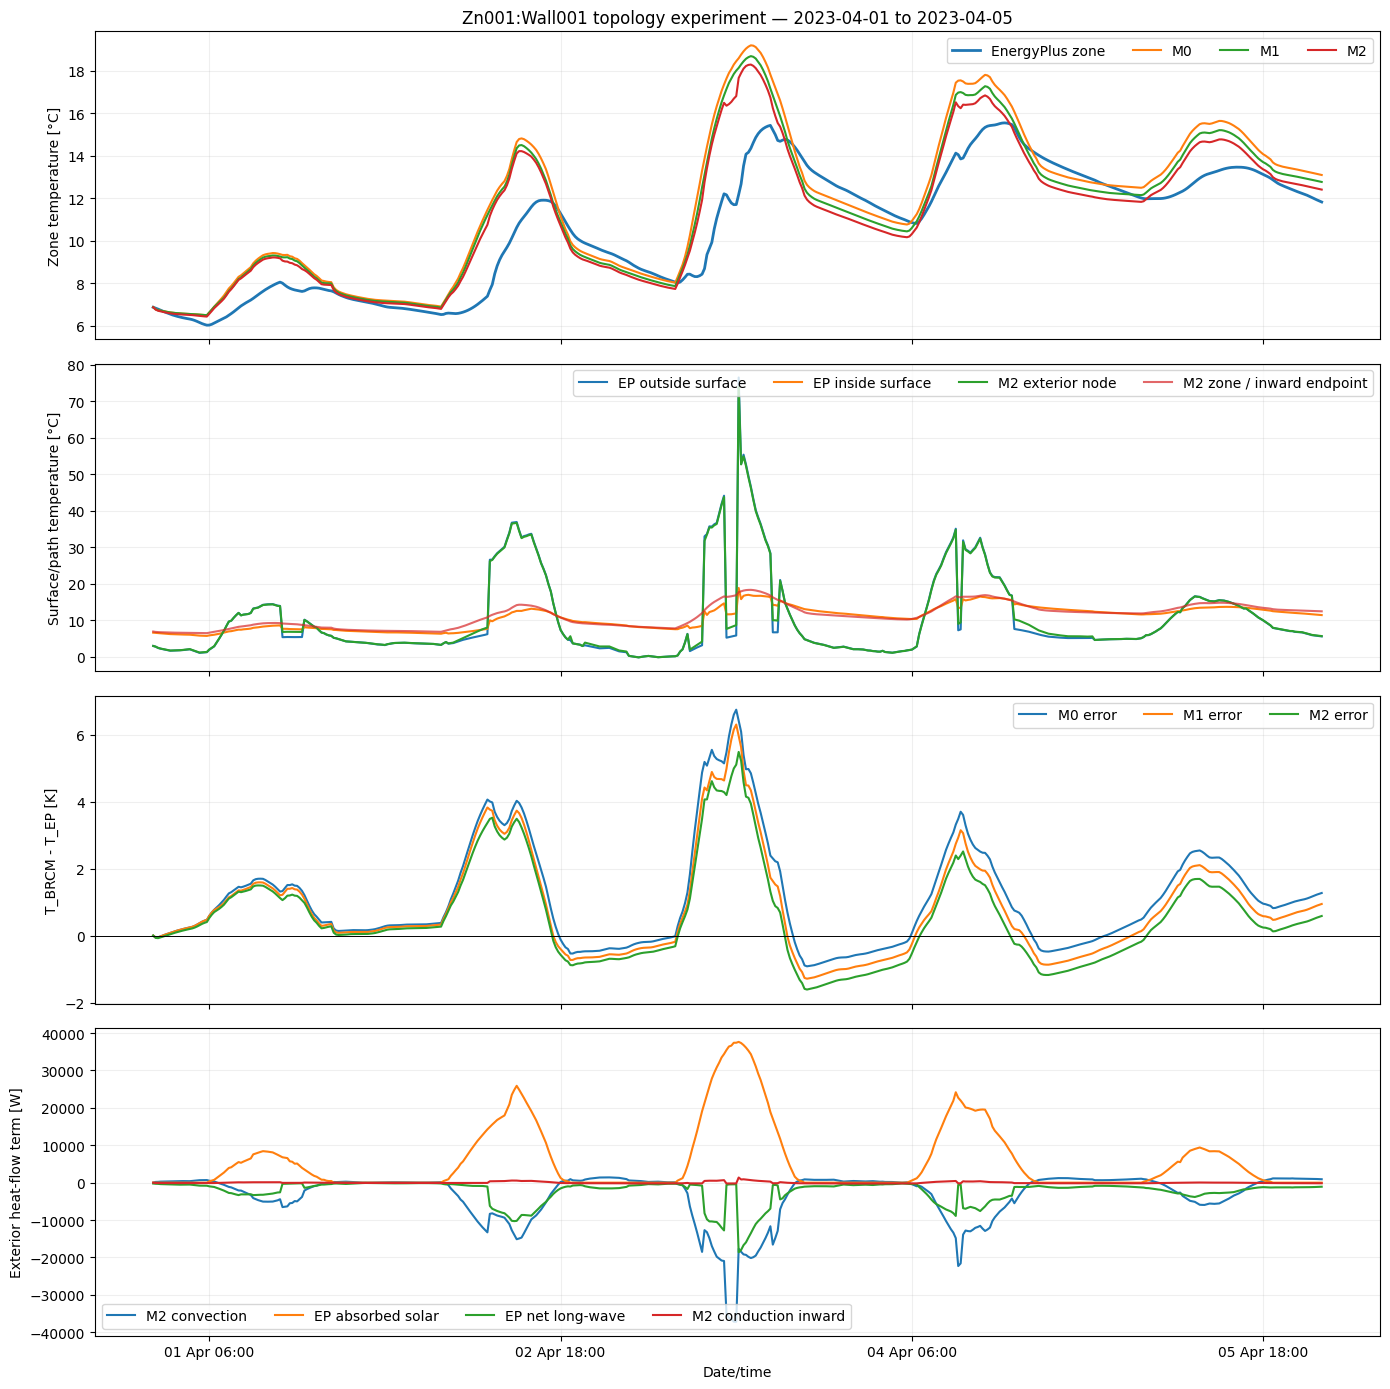

Explicit one-surface topology materially improves parity: YES (+0.380 K RMSE versus M0)


In [9]:
# RC-topology and heat-flow-injection-location experiment (no calibration)
air_transfer_variables = [
    'Zone Air Heat Balance Outdoor Air Transfer Rate',
    'Zone Air Heat Balance Interzone Air Transfer Rate',
    'Zone Air Heat Balance System Air Transfer Rate',
]
air_rows = []
for variable in air_transfer_variables:
    matches = [c for c in ablation_frame.columns if variable.casefold() in c.casefold()]
    if matches:
        signal = ablation_frame[matches].to_numpy(float).sum(axis=1)
        air_rows.append([variable, 'FOUND', '\n'.join(matches), np.mean(np.abs(signal)), np.max(np.abs(signal)), np.mean(np.abs(signal) > 1e-9)])
    else:
        air_rows.append([variable, 'MISSING', '', np.nan, np.nan, np.nan])
air_transfer_audit = pd.DataFrame(air_rows, columns=['Variable', 'Status', 'Exact matched CSV column(s)', 'mean |W|', 'max |W|', 'nonzero fraction'])
display(air_transfer_audit)
air_near_zero = bool((air_transfer_audit['Status'] == 'FOUND').all() and (air_transfer_audit['max |W|'].fillna(np.inf) < 1e-6).all())
print('Infiltration/ventilation:', 'RULED OUT (all three air-transfer signals are near zero)' if air_near_zero else 'NOT ruled out')

construction_map = {c.identifier: c for c in corrected_data.constructions}
nomass_map = {c.identifier: c for c in corrected_data.nomass_constructions}
exterior_elements = [e for e in corrected_data.building_elements if 'AMB' in (e.adjacent_A, e.adjacent_B)]
topology_rows = []
for element in exterior_elements:
    construction = construction_map.get(element.construction_identifier)
    element_states = [x for x in thermal_model.state_identifiers if x.startswith(f'x_{element.identifier}_')]
    massive = bool(element_states)
    exterior_state = next((x for x in element_states if x.endswith(f'{element.adjacent_A}{element.adjacent_B}') and element.adjacent_A == 'AMB'), None)
    if exterior_state is None and element_states and element.adjacent_B == 'AMB': exterior_state = element_states[-1]
    interior_state = element_states[-1] if element.adjacent_A == 'AMB' and element_states else (element_states[0] if element_states else None)
    zone = element.adjacent_B if element.adjacent_A == 'AMB' else element.adjacent_A
    topology_rows.append([element.description, element.identifier, 'layered construction' if construction else 'no-mass construction', 'massive' if massive else 'massless', 'yes' if exterior_state else 'no', 'yes' if interior_state else 'no', f'{zone} zone-air state' if not massive else f'{interior_state} → x_{zone}'])
topology_audit = pd.DataFrame(topology_rows, columns=['EnergyPlus surface', 'BRCM building element', 'Construction type', 'Massive / massless', 'Exterior BRCM state present?', 'Interior state present?', 'Zone connection'])
display(topology_audit)
n_massive_ext = int((topology_audit['Massive / massless'] == 'massive').sum()); n_massless_ext = len(topology_audit) - n_massive_ext
print(f'Exterior elements: {n_massive_ext} massive, {n_massless_ext} massless')
massless_paths = topology_audit.loc[topology_audit['Massive / massless'].eq('massless'), ['EnergyPlus surface', 'BRCM building element']].copy()
massless_paths['Current heat-flow path'] = 'Tamb → combined algebraic construction/film conductance → zone; solar → sol-air equivalent → zone; no explicit long-wave path'
massless_paths['Missing representation'] = 'No exterior- or interior-surface temperature state'
display(massless_paths)

# Select the first simple exterior opaque element and derive every coefficient from converted/EP data.
selected_record = opaque_solar.records[0]
selected_element = selected_record['element']; selected_surface = selected_record['surface']
selected_area = float(selected_record['area']); selected_alpha = float(selected_record['alpha'])
selected_construction = construction_map[selected_element.construction_identifier]
material_map = {m.identifier: m for m in corrected_data.materials}
r_material_area = 0.0
for material_id, thickness_raw in zip(selected_construction.material_identifiers, selected_construction.thickness):
    material = material_map[material_id]
    r_material_area += corrected_data.eval_str(material.R_value) if material.R_value else corrected_data.eval_str(thickness_raw) * corrected_data.eval_str(material.specific_thermal_resistance)
h_ext_fixed = corrected_data.eval_str(selected_construction.conv_coeff_adjacent_A if selected_element.adjacent_A == 'AMB' else selected_construction.conv_coeff_adjacent_B)
h_zone = corrected_data.eval_str(selected_construction.conv_coeff_adjacent_B if selected_element.adjacent_A == 'AMB' else selected_construction.conv_coeff_adjacent_A)
G_inward = 1.0 / (r_material_area / selected_area + 1.0 / (h_zone * selected_area))
G_total_expected = 1.0 / (r_material_area / selected_area + 1.0 / (h_zone * selected_area) + 1.0 / (h_ext_fixed * selected_area))
ambient_bcs = [bc for bc in thermal_model.boundary_conditions['ambient'] if f'x_{ablation_zone.identifier}' in (bc.identifier_1, bc.identifier_2)]
selected_bc = min(ambient_bcs, key=lambda bc: abs(bc.value - G_total_expected))
G_total = float(selected_bc.value)
tau_surface_s = 1.0
C_surface = tau_surface_s * (h_ext_fixed * selected_area + G_inward)
topology_parameters = pd.DataFrame([
    ['Selected surface', selected_surface, '-'], ['Net opaque area', selected_area, 'm²'], ['Exterior solar absorptance', selected_alpha, '-'],
    ['Material R per area', r_material_area, 'm²K/W'], ['Interior film h', h_zone, 'W/m²K'], ['Original exterior film h', h_ext_fixed, 'W/m²K'],
    ['Original combined G', G_total, 'W/K'], ['Surface-to-zone G', G_inward, 'W/K'], ['Diagnostic surface time constant', tau_surface_s, 's'], ['Diagnostic C_s', C_surface, 'J/K'],
], columns=['Quantity', 'Value', 'Unit'])
display(topology_parameters)
print('M2 experimental path: Tamb --dynamic EP h_conv--> x_surface; absorbed solar and net long-wave enter x_surface; x_surface --derived G_inward--> zone.')
print('C_s is a labelled 1-second numerical regularisation for a physically massless surface, not a calibrated material capacitance.')

M0 = E_trajectories['E0 — current equivalence-fixed model']
M1 = E_trajectories['E1 — exact EP window transmitted solar']
m1_model = E_models['E1 — exact EP window transmitted solar']
base_c = m1_model.continuous_time_model
A_base = base_c.A.copy(); Bv_base = base_c.Bv.copy()
zone_i = m1_model.identifiers.x.index(f'x_{ablation_zone.identifier}'); C_zone = thermal_model.Xcap[zone_i, zone_i]
amb_i = m1_model.identifiers.v.index('v_Tamb')
solar_name = selected_record['disturbance']; solar_i = m1_model.identifiers.v.index(solar_name)
A_base[zone_i, zone_i] += G_total / C_zone
Bv_base[zone_i, amb_i] -= G_total / C_zone
Bv_base[zone_i, solar_i] -= (selected_alpha * G_total / h_ext_fixed) / C_zone
v_m1 = exact_model_forcing(m1_model)
ep_h = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Convection Heat Transfer Coefficient', selected_surface)].to_numpy(float)
ep_local_air = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Outdoor Air Drybulb Temperature', selected_surface)].to_numpy(float)
ep_qsolar_surface = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Solar Radiation Heat Gain Rate', selected_surface)].to_numpy(float)
ep_qlw_surface = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Net Thermal Radiation Heat Gain Rate', selected_surface)].to_numpy(float)
ep_ts_out = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', selected_surface)].to_numpy(float)
ep_ts_in = ablation_frame[column_in(ablation_frame, 'Surface Inside Face Temperature', selected_surface)].to_numpy(float)
y = np.concatenate([x0_resistance[:, 0], [ep_ts_out[0]]]); M2_full = np.zeros((len(y), n_ablation)); M2_full[:, 0] = y
qconv_m2 = np.zeros(n_ablation); qcond_m2 = np.zeros(n_ablation)
for k in range(n_ablation - 1):
    hA = ep_h[k + 1] * selected_area
    A_step = np.zeros((len(y), len(y))); A_step[:-1, :-1] = A_base
    A_step[zone_i, zone_i] -= G_inward / C_zone; A_step[zone_i, -1] += G_inward / C_zone
    A_step[-1, zone_i] = G_inward / C_surface; A_step[-1, -1] = -(hA + G_inward) / C_surface
    forcing = np.zeros(len(y)); forcing[:-1] = Bv_base @ v_m1[:, k]
    forcing[-1] = (hA * ep_local_air[k + 1] + ep_qsolar_surface[k + 1] + ep_qlw_surface[k + 1]) / C_surface
    Ad_step, Bd_step = brcm.BuildingModel._zoh(A_step, forcing[:, None], TS_HRS * 3600.0)
    y = Ad_step @ y + Bd_step[:, 0]; M2_full[:, k + 1] = y
    qconv_m2[k + 1] = hA * (ep_local_air[k + 1] - y[-1]); qcond_m2[k + 1] = G_inward * (y[-1] - y[zone_i])
M2 = M2_full[zone_i]; M2_surface = M2_full[-1]

def topology_metrics(label, values):
    error = values - ablation_ep; rmse = float(np.sqrt(np.mean(error**2))); mean_ep = float(np.mean(ablation_ep))
    return [label, rmse, 100*rmse/mean_ep, 100*float(np.mean(error))/mean_ep, float(np.mean(np.abs(error))), float(np.max(np.abs(error)))]
M_summary = pd.DataFrame([topology_metrics('M0 — equivalence-fixed', M0), topology_metrics('M1 — exact EP transmitted-window solar', M1), topology_metrics('M2 — M1 + explicit exterior node on one surface', M2)], columns=['Case', 'RMSE [K]', 'CVRMSE [%]', 'NMBE [%]', 'MAE [K]', 'Max error [K]'])
M_summary['Improvement vs M0 [K RMSE]'] = M_summary.iloc[0]['RMSE [K]'] - M_summary['RMSE [K]']
display(M_summary.round(3))

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
axes[0].plot(ablation_times, ablation_ep, label='EnergyPlus zone', linewidth=2); axes[0].plot(ablation_times, M0, label='M0'); axes[0].plot(ablation_times, M1, label='M1'); axes[0].plot(ablation_times, M2, label='M2'); axes[0].set_ylabel('Zone temperature [°C]'); axes[0].legend(ncol=4); axes[0].grid(alpha=.2)
axes[1].plot(ablation_times, ep_ts_out, label='EP outside surface'); axes[1].plot(ablation_times, ep_ts_in, label='EP inside surface'); axes[1].plot(ablation_times, M2_surface, label='M2 exterior node'); axes[1].plot(ablation_times, M2, label='M2 zone / inward endpoint', alpha=.7); axes[1].set_ylabel('Surface/path temperature [°C]'); axes[1].legend(ncol=4); axes[1].grid(alpha=.2)
axes[2].plot(ablation_times, M0-ablation_ep, label='M0 error'); axes[2].plot(ablation_times, M1-ablation_ep, label='M1 error'); axes[2].plot(ablation_times, M2-ablation_ep, label='M2 error'); axes[2].axhline(0,color='black',linewidth=.7); axes[2].set_ylabel('T_BRCM - T_EP [K]'); axes[2].legend(ncol=3); axes[2].grid(alpha=.2)
axes[3].plot(ablation_times, qconv_m2, label='M2 convection'); axes[3].plot(ablation_times, ep_qsolar_surface, label='EP absorbed solar'); axes[3].plot(ablation_times, ep_qlw_surface, label='EP net long-wave'); axes[3].plot(ablation_times, qcond_m2, label='M2 conduction inward'); axes[3].set_ylabel('Exterior heat-flow term [W]'); axes[3].legend(ncol=4); axes[3].grid(alpha=.2); axes[3].set_xlabel('Date/time')
axes[0].set_title(f'{selected_surface} topology experiment — {diagnostic["start"]} to {diagnostic["end"]}')
axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=36)); axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()
m2_improvement = float(M_summary.iloc[2]['Improvement vs M0 [K RMSE]'])
print('Explicit one-surface topology materially improves parity:' , 'YES' if m2_improvement >= 0.2 else 'NO', f'({m2_improvement:+.3f} K RMSE versus M0)')


,Desired variable,Status,Exact matched CSV column(s)
0,Surface Outside Face Thermal Radiation to Sky ...,FOUND,ZN001:WALL001:Surface Outside Face Thermal Rad...
1,Site Sky Temperature,FOUND,Environment:Site Sky Temperature [C](TimeStep)
2,Surface Outside Face Temperature,FOUND,ZN001:WALL001:Surface Outside Face Temperature...
3,Surface Outside Face Thermal Radiation to Grou...,FOUND,ZN001:WALL001:Surface Outside Face Thermal Rad...
4,Site Ground Temperature,FOUND,Environment:Site Ground Temperature [C](TimeStep)
5,Surface Outside Face Thermal Radiation to Air ...,FOUND,ZN001:WALL001:Surface Outside Face Thermal Rad...
6,Surface Outside Face Net Thermal Radiation Hea...,FOUND,ZN001:WALL001:Surface Outside Face Net Thermal...


,Surface,Converted net area [m²],mean q_sky [W],mean q_ground [W],mean q_air radiation [W],mean |component sum - net| [W],max |component sum - net| [W],Heat-gain sign confirmed?
0,Zn001:Wall001,59.67728,-1546.427801,1119.697823,182.771545,2095.813362,6818.408192,True
1,Zn001:Wall002,69.67728,-1586.999148,1605.714625,125.823597,2295.945923,7433.443812,True
2,Zn001:Wall003,69.67728,-1356.729065,1908.320071,30.536675,2082.609578,3023.845358,False
3,Zn001:Wall004,69.67728,-1624.189354,1549.019612,141.248888,2322.779079,5107.367734,True
4,Zn001:Roof001,232.25760,-14470.455990,0.000000,0.000000,0.000000,0.000000,True


Aggregate long-wave reconciliation residual: mean |residual|=8797.147942 W; max |residual|=17269.692400 W
EnergyPlus heat-gain sign convention confirmed for every surface: False


,Case,RMSE [K],CVRMSE [%],NMBE [%],MAE [K],Max error [K],RMSE change vs no-long-wave M3a [K]
0,M1 — exact transmitted-window solar,1.680,15.791,7.501,1.182,6.305,0.186
1,"M3a — five exterior nodes, no exterior long-wave",1.866,17.542,9.166,1.276,7.747,0.000
2,M3b — five exterior nodes + reconstructed sky/...,1.468,13.804,4.230,1.130,5.515,0.398


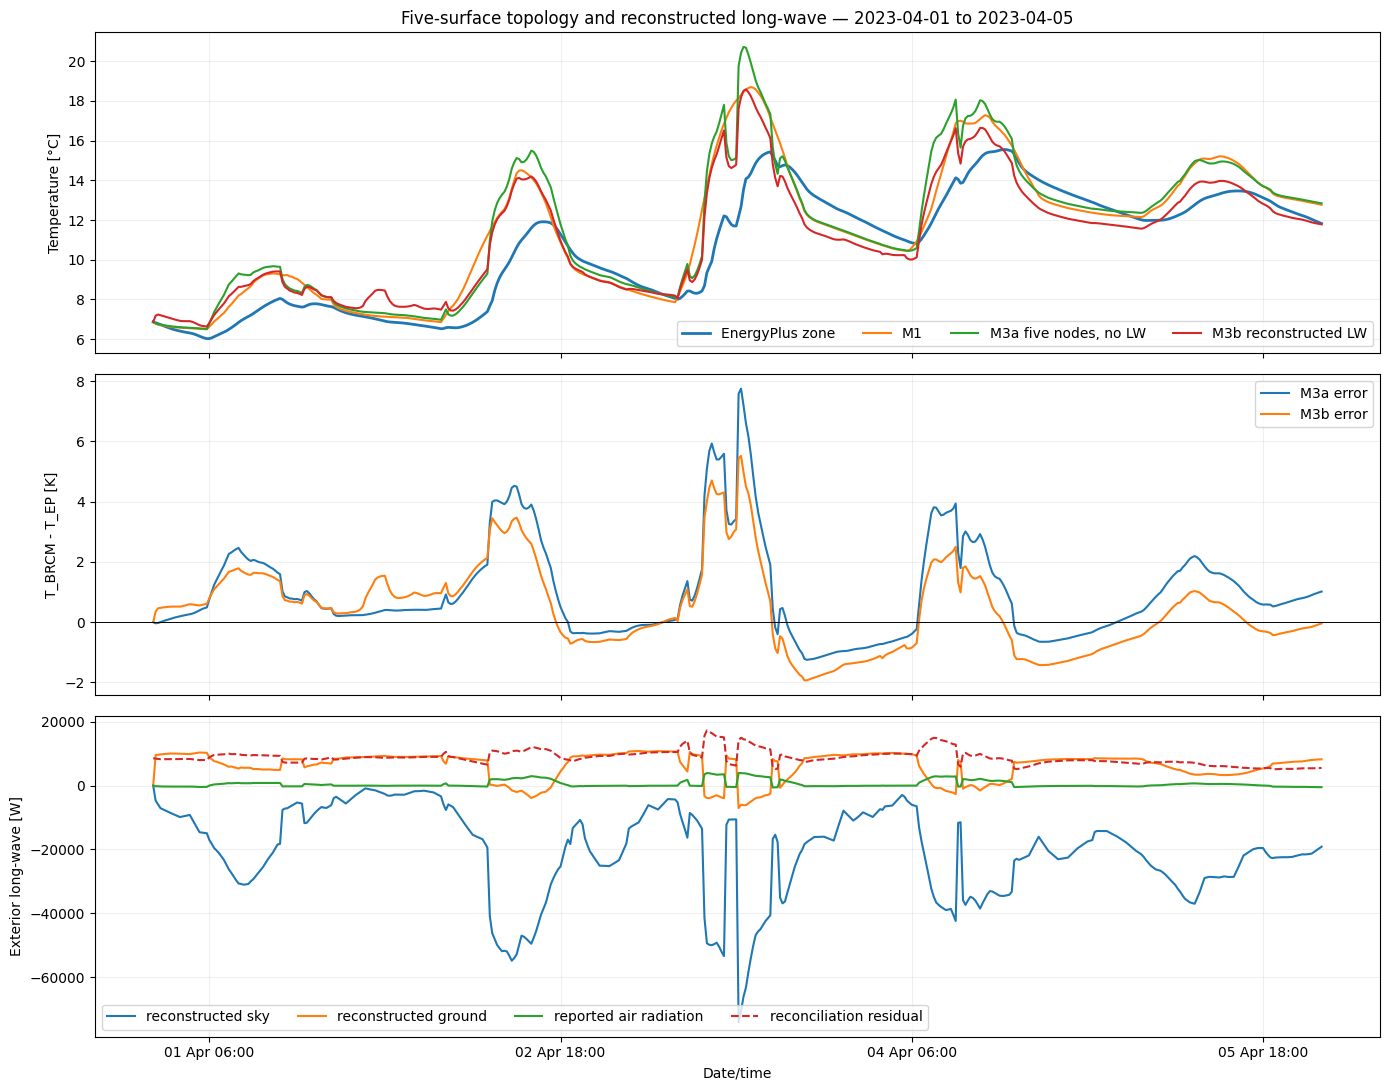

Reconstructed exterior long-wave RMSE effect: 1.866 -> 1.468 K (+0.398 K improvement).
Long-wave materially explains residual: YES


In [10]:
# Reconstruct exterior sky/ground long-wave and apply it at explicit surface nodes.
longwave_desired = [
    'Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient',
    'Site Sky Temperature',
    'Surface Outside Face Temperature',
    'Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient',
    'Site Ground Temperature',
    'Surface Outside Face Thermal Radiation to Air Heat Transfer Rate',
    'Surface Outside Face Net Thermal Radiation Heat Gain Rate',
]
longwave_audit_rows = []
for variable in longwave_desired:
    matches = [c for c in ablation_frame.columns if variable.casefold() in c.casefold()]
    longwave_audit_rows.append([variable, 'FOUND' if matches else 'MISSING', '\n'.join(matches)])
longwave_variable_audit = pd.DataFrame(longwave_audit_rows, columns=['Desired variable', 'Status', 'Exact matched CSV column(s)'])
display(longwave_variable_audit)
if not (longwave_variable_audit['Status'] == 'FOUND').all():
    raise RuntimeError('A required long-wave reconstruction variable is missing; no silent substitution is permitted.')

sky_temperature = ablation_frame[column_in(ablation_frame, 'Site Sky Temperature')].to_numpy(float)
ground_temperature = ablation_frame[column_in(ablation_frame, 'Site Ground Temperature')].to_numpy(float)
surface_lw = {}
reconciliation_rows = []
for record in opaque_solar.records:
    surface, area = record['surface'], float(record['area'])
    t_surface_ep = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', surface)].to_numpy(float)
    h_sky = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient', surface)].to_numpy(float)
    h_ground = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient', surface)].to_numpy(float)
    q_air = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Thermal Radiation to Air Heat Transfer Rate', surface)].to_numpy(float)
    q_net = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Net Thermal Radiation Heat Gain Rate', surface)].to_numpy(float)
    q_sky = h_sky * area * (sky_temperature - t_surface_ep)
    q_ground = h_ground * area * (ground_temperature - t_surface_ep)
    q_sum = q_sky + q_ground + q_air
    residual = q_sum - q_net
    reverse_residual = -q_sky - q_ground + q_air - q_net
    sign_confirmed = np.mean(np.abs(residual)) <= np.mean(np.abs(reverse_residual))
    surface_lw[record['element'].identifier] = {'q_sky': q_sky, 'q_ground': q_ground, 'q_air': q_air, 'q_net': q_net, 'q_sum': q_sum, 'residual': residual}
    reconciliation_rows.append([surface, area, np.mean(q_sky), np.mean(q_ground), np.mean(q_air), np.mean(np.abs(residual)), np.max(np.abs(residual)), sign_confirmed])
longwave_reconciliation = pd.DataFrame(reconciliation_rows, columns=['Surface', 'Converted net area [m²]', 'mean q_sky [W]', 'mean q_ground [W]', 'mean q_air radiation [W]', 'mean |component sum - net| [W]', 'max |component sum - net| [W]', 'Heat-gain sign confirmed?'])
display(longwave_reconciliation.round(6))
aggregate_residual = np.sum([item['residual'] for item in surface_lw.values()], axis=0)
aggregate_mean_abs_residual = float(np.mean(np.abs(aggregate_residual))); aggregate_max_abs_residual = float(np.max(np.abs(aggregate_residual)))
print(f'Aggregate long-wave reconciliation residual: mean |residual|={aggregate_mean_abs_residual:.6f} W; max |residual|={aggregate_max_abs_residual:.6f} W')
print('EnergyPlus heat-gain sign convention confirmed for every surface:', bool(longwave_reconciliation['Heat-gain sign confirmed?'].all()))

def exterior_record_parameters(record):
    element = record['element']; construction = construction_map[element.construction_identifier]; area = float(record['area'])
    r_area = 0.0
    for material_id, thickness_raw in zip(construction.material_identifiers, construction.thickness):
        material = material_map[material_id]
        r_area += corrected_data.eval_str(material.R_value) if material.R_value else corrected_data.eval_str(thickness_raw) * corrected_data.eval_str(material.specific_thermal_resistance)
    h_ext = corrected_data.eval_str(construction.conv_coeff_adjacent_A if element.adjacent_A == 'AMB' else construction.conv_coeff_adjacent_B)
    h_int = corrected_data.eval_str(construction.conv_coeff_adjacent_B if element.adjacent_A == 'AMB' else construction.conv_coeff_adjacent_A)
    g_in = 1.0 / (r_area / area + 1.0 / (h_int * area))
    g_expected = 1.0 / (r_area / area + 1.0 / (h_int * area) + 1.0 / (h_ext * area))
    bc = min(ambient_bcs, key=lambda candidate: abs(candidate.value - g_expected))
    return {'record': record, 'area': area, 'h_ext': h_ext, 'h_int': h_int, 'G_in': g_in, 'G_total': float(bc.value), 'C_s': h_ext * area + g_in}
all_surface_parameters = [exterior_record_parameters(record) for record in opaque_solar.records]

# Start from M1. Remove all five algebraic ambient and sol-air paths, then add five surface nodes.
A_all = base_c.A.copy(); Bv_all = base_c.Bv.copy()
for item in all_surface_parameters:
    record = item['record']; solar_index = m1_model.identifiers.v.index(record['disturbance'])
    A_all[zone_i, zone_i] += item['G_total'] / C_zone
    Bv_all[zone_i, amb_i] -= item['G_total'] / C_zone
    Bv_all[zone_i, solar_index] -= (float(record['alpha']) * item['G_total'] / item['h_ext']) / C_zone

def simulate_all_exterior_nodes(include_reconstructed_longwave):
    nx, ns = len(m1_model.identifiers.x), len(all_surface_parameters)
    initial_surfaces = [ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', item['record']['surface'])].iloc[0] for item in all_surface_parameters]
    state = np.concatenate([x0_resistance[:, 0], initial_surfaces]); history = np.zeros((nx + ns, n_ablation)); history[:, 0] = state
    term_history = {key: np.zeros((ns, n_ablation)) for key in ('convection', 'solar', 'sky', 'ground', 'air_radiation', 'conduction_inward')}
    for k in range(n_ablation - 1):
        A_step = np.zeros((nx + ns, nx + ns)); A_step[:nx, :nx] = A_all
        forcing = np.zeros(nx + ns); forcing[:nx] = Bv_all @ v_m1[:, k]
        for j, item in enumerate(all_surface_parameters):
            record, surface, area = item['record'], item['record']['surface'], item['area']; si = nx + j
            h_value = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Convection Heat Transfer Coefficient', surface)].iloc[k + 1]
            t_air = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Outdoor Air Drybulb Temperature', surface)].iloc[k + 1]
            q_solar = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Solar Radiation Heat Gain Rate', surface)].iloc[k + 1]
            lw = surface_lw[record['element'].identifier]; q_lw = (lw['q_sky'][k + 1] + lw['q_ground'][k + 1] + lw['q_air'][k + 1]) if include_reconstructed_longwave else 0.0
            hA, g_in, cap = h_value * area, item['G_in'], item['C_s']
            A_step[zone_i, zone_i] -= g_in / C_zone; A_step[zone_i, si] += g_in / C_zone
            A_step[si, zone_i] = g_in / cap; A_step[si, si] = -(hA + g_in) / cap
            forcing[si] = (hA * t_air + q_solar + q_lw) / cap
            term_history['solar'][j, k + 1] = q_solar; term_history['sky'][j, k + 1] = lw['q_sky'][k + 1] if include_reconstructed_longwave else 0.0; term_history['ground'][j, k + 1] = lw['q_ground'][k + 1] if include_reconstructed_longwave else 0.0; term_history['air_radiation'][j, k + 1] = lw['q_air'][k + 1] if include_reconstructed_longwave else 0.0
        Ad_step, Bd_step = brcm.BuildingModel._zoh(A_step, forcing[:, None], TS_HRS * 3600.0)
        state = Ad_step @ state + Bd_step[:, 0]; history[:, k + 1] = state
        for j, item in enumerate(all_surface_parameters):
            surface, area, si = item['record']['surface'], item['area'], nx + j
            h_value = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Convection Heat Transfer Coefficient', surface)].iloc[k + 1]
            t_air = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Outdoor Air Drybulb Temperature', surface)].iloc[k + 1]
            term_history['convection'][j, k + 1] = h_value * area * (t_air - state[si]); term_history['conduction_inward'][j, k + 1] = item['G_in'] * (state[si] - state[zone_i])
    return history, term_history

M3_no_lw_full, M3_no_lw_terms = simulate_all_exterior_nodes(False)
M3_lw_full, M3_lw_terms = simulate_all_exterior_nodes(True)
M3_no_lw, M3_lw = M3_no_lw_full[zone_i], M3_lw_full[zone_i]
longwave_model_summary = pd.DataFrame([topology_metrics('M1 — exact transmitted-window solar', M1), topology_metrics('M3a — five exterior nodes, no exterior long-wave', M3_no_lw), topology_metrics('M3b — five exterior nodes + reconstructed sky/ground/air long-wave', M3_lw)], columns=['Case', 'RMSE [K]', 'CVRMSE [%]', 'NMBE [%]', 'MAE [K]', 'Max error [K]'])
longwave_model_summary['RMSE change vs no-long-wave M3a [K]'] = float(longwave_model_summary.iloc[1]['RMSE [K]']) - longwave_model_summary['RMSE [K]']
display(longwave_model_summary.round(3))

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
axes[0].plot(ablation_times, ablation_ep, label='EnergyPlus zone', linewidth=2); axes[0].plot(ablation_times, M1, label='M1'); axes[0].plot(ablation_times, M3_no_lw, label='M3a five nodes, no LW'); axes[0].plot(ablation_times, M3_lw, label='M3b reconstructed LW'); axes[0].set_ylabel('Temperature [°C]'); axes[0].legend(ncol=4); axes[0].grid(alpha=.2)
axes[1].plot(ablation_times, M3_no_lw-ablation_ep, label='M3a error'); axes[1].plot(ablation_times, M3_lw-ablation_ep, label='M3b error'); axes[1].axhline(0,color='black',linewidth=.7); axes[1].set_ylabel('T_BRCM - T_EP [K]'); axes[1].legend(); axes[1].grid(alpha=.2)
axes[2].plot(ablation_times, np.sum(M3_lw_terms['sky'], axis=0), label='reconstructed sky'); axes[2].plot(ablation_times, np.sum(M3_lw_terms['ground'], axis=0), label='reconstructed ground'); axes[2].plot(ablation_times, np.sum(M3_lw_terms['air_radiation'], axis=0), label='reported air radiation'); axes[2].plot(ablation_times, aggregate_residual, label='reconciliation residual', linestyle='--'); axes[2].set_ylabel('Exterior long-wave [W]'); axes[2].set_xlabel('Date/time'); axes[2].legend(ncol=4); axes[2].grid(alpha=.2)
axes[0].set_title(f'Five-surface topology and reconstructed long-wave — {diagnostic["start"]} to {diagnostic["end"]}'); axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=36)); axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()
lw_rmse_before = float(longwave_model_summary.iloc[1]['RMSE [K]']); lw_rmse_after = float(longwave_model_summary.iloc[2]['RMSE [K]']); lw_improvement = lw_rmse_before - lw_rmse_after
print(f'Reconstructed exterior long-wave RMSE effect: {lw_rmse_before:.3f} -> {lw_rmse_after:.3f} K ({lw_improvement:+.3f} K improvement).')
print('Long-wave materially explains residual:', 'YES' if lw_improvement >= 0.2 else 'NO')


,Candidate ground/surroundings temperature,Status,Exact matched CSV column(s)
0,Site Ground Temperature,FOUND,Environment:Site Ground Temperature [C](TimeStep)
1,Site Surface Ground Temperature,FOUND,Environment:Site Surface Ground Temperature [C...
2,Site Deep Ground Temperature,FOUND,Environment:Site Deep Ground Temperature [C](T...
3,Site Simple Factor Model Ground Temperature,FOUND,Environment:Site Simple Factor Model Ground Te...


Ground/surroundings temperature variables advertised by this run RDD:
Zone,Average,Site Ground Temperature [C]
Zone,Average,Site Surface Ground Temperature [C]
Zone,Average,Site Deep Ground Temperature [C]
Zone,Average,Site Simple Factor Model Ground Temperature [C]


,Ground reference candidate,Surface,mean |residual| [W],max |residual| [W]
0,Site Ground Temperature,Zn001:Wall001,2095.813362,6818.408192
1,Site Ground Temperature,Zn001:Wall002,2295.945923,7433.443812
2,Site Ground Temperature,Zn001:Wall003,2082.609578,3023.845358
3,Site Ground Temperature,Zn001:Wall004,2322.779079,5107.367734
4,Site Ground Temperature,Zn001:Roof001,0.000000,0.000000
5,Site Surface Ground Temperature,Zn001:Wall001,1264.943706,5704.147560
6,Site Surface Ground Temperature,Zn001:Wall002,1335.024217,6236.085749
7,Site Surface Ground Temperature,Zn001:Wall003,1131.771858,2065.032529
8,Site Surface Ground Temperature,Zn001:Wall004,1360.379041,3966.941094
9,Site Surface Ground Temperature,Zn001:Roof001,0.000000,0.000000


,Ground reference candidate,mean per-surface |residual| [W],maximum |residual| [W],aggregate mean |residual| [W],aggregate max |residual| [W]
4,Surface-local outdoor dry-bulb (diagnostic can...,263.038384,5063.621319,1293.491758,7715.375205
2,Site Simple Factor Model Ground Temperature,388.036240,4905.687901,1812.754879,8772.921222
3,Site Surface Ground Temperature,1018.423764,6236.085749,5092.118821,13244.906053
0,Site Deep Ground Temperature,1381.661913,6823.025976,6908.309566,15217.840537
1,Site Ground Temperature,1759.429588,7433.443812,8797.147942,17269.692400


Ground radiant reference resolved from an exported variable: False
Best exported/diagnostic candidate: Surface-local outdoor dry-bulb (diagnostic candidate) aggregate mean/max |residual| [W]: 1293.4917581719942 7715.375205122304


,Case,RMSE [K],CVRMSE [%],NMBE [%],MAE [K],Max error [K],Improvement vs M3b [K RMSE]
0,M1 — exact window solar,1.680,15.791,7.501,1.182,6.305,-0.211
1,M3b — five capacitive nodes + reconstructed LW,1.468,13.804,4.230,1.130,5.515,0.000
2,M4 — algebraic massless surfaces,1.469,13.805,4.233,1.130,5.517,-0.000


M5 was not run because no exported ground/surroundings temperature reconciled the EnergyPlus net long-wave balance; no inferred/fitted reference is substituted.


,C_s per exterior node [J/K],RMSE [K],CVRMSE [%],NMBE [%],MAE [K],Max error [K]
0,1.0,1.468627,13.805397,4.232945,1.129934,5.516766
1,10.0,1.468625,13.805384,4.232914,1.129934,5.516749
2,100.0,1.468612,13.805262,4.232673,1.129929,5.516596
3,1000.0,1.468483,13.804042,4.230272,1.129882,5.515061


Capacitance sensitivity: RMSE span=0.000144 K; maximum cross-case zone-temperature spread=0.005097 K


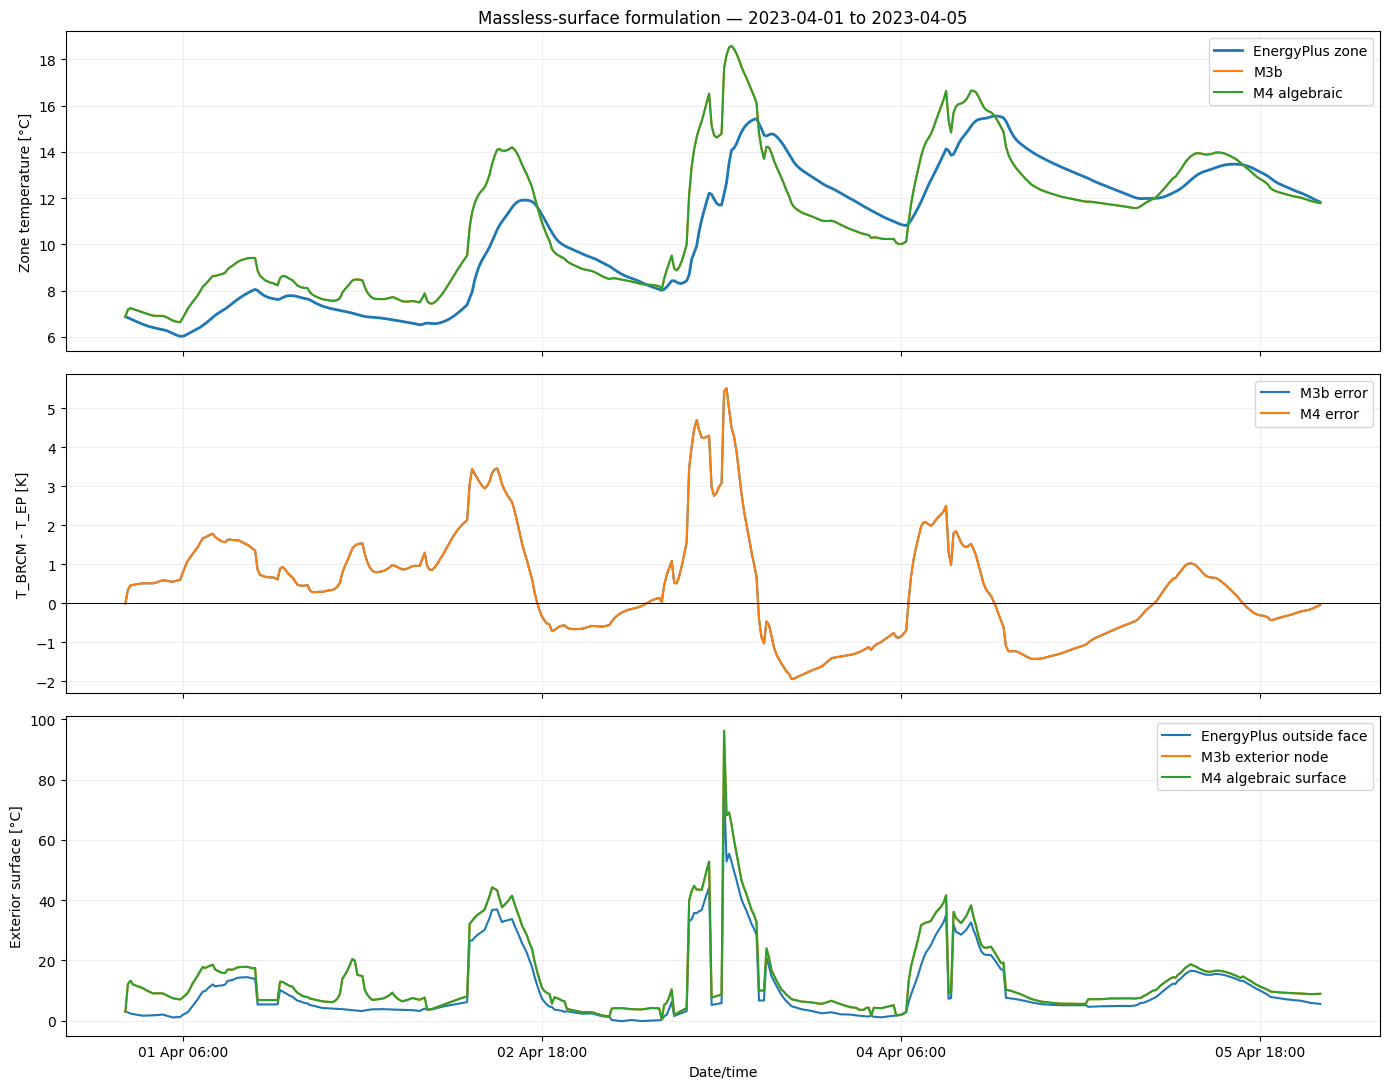

In [11]:
# Ground-reference audit, algebraic massless surfaces, and capacitance sensitivity.
ground_reference_candidates = [
    'Site Ground Temperature',
    'Site Surface Ground Temperature',
    'Site Deep Ground Temperature',
    'Site Simple Factor Model Ground Temperature',
]
ground_reference_rows = []
ground_candidate_signals = {}
for variable in ground_reference_candidates:
    matches = [c for c in ablation_frame.columns if variable.casefold() in c.casefold()]
    if matches:
        ground_candidate_signals[variable] = ablation_frame[matches[0]].to_numpy(float)
    ground_reference_rows.append([variable, 'FOUND' if matches else 'MISSING', '\n'.join(matches)])
ground_reference_audit = pd.DataFrame(ground_reference_rows, columns=['Candidate ground/surroundings temperature', 'Status', 'Exact matched CSV column(s)'])
display(ground_reference_audit)
rdd_path = diagnostic['output_dir'] / 'eplusout.rdd'
rdd_ground_temperature_names = [line.strip() for line in rdd_path.read_text(errors='replace').splitlines() if 'temperature' in line.casefold() and ('ground' in line.casefold() or 'surround' in line.casefold())]
print('Ground/surroundings temperature variables advertised by this run RDD:')
for line in rdd_ground_temperature_names: print(line)

def reconcile_ground_reference(label, ground_signal):
    rows, aggregate = [], np.zeros(n_ablation)
    for record in opaque_solar.records:
        surface, area = record['surface'], float(record['area']); lw = surface_lw[record['element'].identifier]
        ts = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', surface)].to_numpy(float)
        hg = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient', surface)].to_numpy(float)
        q_ground_candidate = hg * area * (ground_signal - ts)
        residual = lw['q_sky'] + q_ground_candidate + lw['q_air'] - lw['q_net']; aggregate += residual
        rows.append([label, surface, np.mean(np.abs(residual)), np.max(np.abs(residual))])
    return rows, aggregate
ground_reconciliation_rows, ground_aggregate = [], {}
for label, signal in ground_candidate_signals.items():
    rows, residual = reconcile_ground_reference(label, signal); ground_reconciliation_rows.extend(rows); ground_aggregate[label] = residual
# Local outside dry-bulb is a documented surface output and a physically relevant non-ground-table candidate.
local_air_candidate = np.mean(np.vstack([ablation_frame[column_in(ablation_frame, 'Surface Outside Face Outdoor Air Drybulb Temperature', record['surface'])].to_numpy(float) for record in opaque_solar.records]), axis=0)
rows, residual = reconcile_ground_reference('Surface-local outdoor dry-bulb (diagnostic candidate)', local_air_candidate); ground_reconciliation_rows.extend(rows); ground_aggregate['Surface-local outdoor dry-bulb (diagnostic candidate)'] = residual
ground_reconciliation_audit = pd.DataFrame(ground_reconciliation_rows, columns=['Ground reference candidate', 'Surface', 'mean |residual| [W]', 'max |residual| [W]'])
display(ground_reconciliation_audit.round(6))
ground_candidate_summary = ground_reconciliation_audit.groupby('Ground reference candidate', as_index=False).agg(**{'mean per-surface |residual| [W]':('mean |residual| [W]','mean'), 'maximum |residual| [W]':('max |residual| [W]','max')})
ground_candidate_summary['aggregate mean |residual| [W]'] = ground_candidate_summary['Ground reference candidate'].map(lambda key: np.mean(np.abs(ground_aggregate[key])))
ground_candidate_summary['aggregate max |residual| [W]'] = ground_candidate_summary['Ground reference candidate'].map(lambda key: np.max(np.abs(ground_aggregate[key])))
display(ground_candidate_summary.sort_values('aggregate mean |residual| [W]').round(6))
best_ground_row = ground_candidate_summary.loc[ground_candidate_summary['aggregate mean |residual| [W]'].idxmin()]
ground_reference_resolved = bool(best_ground_row['aggregate max |residual| [W]'] < 1e-3)
print('Ground radiant reference resolved from an exported variable:', ground_reference_resolved)
print('Best exported/diagnostic candidate:', best_ground_row['Ground reference candidate'], 'aggregate mean/max |residual| [W]:', best_ground_row['aggregate mean |residual| [W]'], best_ground_row['aggregate max |residual| [W]'])

def longwave_for_reference(item, k, ground_signal):
    record, surface, area = item['record'], item['record']['surface'], item['area']; lw = surface_lw[record['element'].identifier]
    ts_ep = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', surface)].iloc[k]
    hg = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient', surface)].iloc[k]
    return lw['q_sky'][k] + hg * area * (ground_signal[k] - ts_ep) + lw['q_air'][k]

def simulate_algebraic_massless(ground_signal):
    state = x0_resistance[:, 0].copy(); history = np.zeros((len(state), n_ablation)); history[:, 0] = state
    surface_history = np.zeros((len(all_surface_parameters), n_ablation))
    for j, item in enumerate(all_surface_parameters): surface_history[j, 0] = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', item['record']['surface'])].iloc[0]
    for k in range(n_ablation - 1):
        A_step = A_all.copy(); forcing = Bv_all @ v_m1[:, k]
        coefficients = []
        for j, item in enumerate(all_surface_parameters):
            surface, area = item['record']['surface'], item['area']; h = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Convection Heat Transfer Coefficient', surface)].iloc[k + 1]; hA = h * area
            t_air = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Outdoor Air Drybulb Temperature', surface)].iloc[k + 1]; qsolar = ablation_frame[column_in(ablation_frame, 'Surface Outside Face Solar Radiation Heat Gain Rate', surface)].iloc[k + 1]; qlw = longwave_for_reference(item, k + 1, ground_signal)
            denominator = hA + item['G_in']; geq = item['G_in'] * hA / denominator; source = item['G_in'] * (hA * t_air + qsolar + qlw) / denominator
            A_step[zone_i, zone_i] -= geq / C_zone; forcing[zone_i] += source / C_zone; coefficients.append((hA, t_air, qsolar, qlw, item['G_in'], denominator))
        Ad_step, Bd_step = brcm.BuildingModel._zoh(A_step, forcing[:, None], TS_HRS * 3600.0); state = Ad_step @ state + Bd_step[:, 0]; history[:, k + 1] = state
        for j, (hA, t_air, qsolar, qlw, g_in, denominator) in enumerate(coefficients): surface_history[j, k + 1] = (hA*t_air + qsolar + qlw + g_in*state[zone_i]) / denominator
    return history, surface_history

M4_full, M4_surfaces = simulate_algebraic_massless(ground_candidate_signals['Site Ground Temperature'])
M4 = M4_full[zone_i]
if ground_reference_resolved:
    resolved_ground_label = str(best_ground_row['Ground reference candidate']); M5_full, M5_surfaces = simulate_algebraic_massless(ground_candidate_signals.get(resolved_ground_label, local_air_candidate)); M5 = M5_full[zone_i]
else:
    resolved_ground_label = None; M5_full = M5_surfaces = M5 = None
comparison_rows = [topology_metrics('M1 — exact window solar', M1), topology_metrics('M3b — five capacitive nodes + reconstructed LW', M3_lw), topology_metrics('M4 — algebraic massless surfaces', M4)]
if M5 is not None: comparison_rows.append(topology_metrics(f'M5 — M4 + resolved ground reference ({resolved_ground_label})', M5))
M45_summary = pd.DataFrame(comparison_rows, columns=['Case','RMSE [K]','CVRMSE [%]','NMBE [%]','MAE [K]','Max error [K]']); M45_summary['Improvement vs M3b [K RMSE]'] = float(M45_summary.iloc[1]['RMSE [K]']) - M45_summary['RMSE [K]']
display(M45_summary.round(3))
if M5 is None: print('M5 was not run because no exported ground/surroundings temperature reconciled the EnergyPlus net long-wave balance; no inferred/fitted reference is substituted.')

def simulate_capacitance_value(capacitance_j_per_k):
    nx, ns = len(m1_model.identifiers.x), len(all_surface_parameters); initial = [ablation_frame[column_in(ablation_frame, 'Surface Outside Face Temperature', item['record']['surface'])].iloc[0] for item in all_surface_parameters]
    state=np.concatenate([x0_resistance[:,0],initial]); history=np.zeros((nx+ns,n_ablation)); history[:,0]=state
    for k in range(n_ablation-1):
        A_step=np.zeros((nx+ns,nx+ns)); A_step[:nx,:nx]=A_all; forcing=np.zeros(nx+ns); forcing[:nx]=Bv_all@v_m1[:,k]
        for j,item in enumerate(all_surface_parameters):
            surface,area,si=item['record']['surface'],item['area'],nx+j; h=ablation_frame[column_in(ablation_frame,'Surface Outside Face Convection Heat Transfer Coefficient',surface)].iloc[k+1]; hA=h*area; t_air=ablation_frame[column_in(ablation_frame,'Surface Outside Face Outdoor Air Drybulb Temperature',surface)].iloc[k+1]; qsolar=ablation_frame[column_in(ablation_frame,'Surface Outside Face Solar Radiation Heat Gain Rate',surface)].iloc[k+1]; qlw=longwave_for_reference(item,k+1,ground_candidate_signals['Site Ground Temperature']); g=item['G_in']
            A_step[zone_i,zone_i]-=g/C_zone; A_step[zone_i,si]+=g/C_zone; A_step[si,zone_i]=g/capacitance_j_per_k; A_step[si,si]=-(hA+g)/capacitance_j_per_k; forcing[si]=(hA*t_air+qsolar+qlw)/capacitance_j_per_k
        Ad,Bd=brcm.BuildingModel._zoh(A_step,forcing[:,None],TS_HRS*3600); state=Ad@state+Bd[:,0]; history[:,k+1]=state
    return history
capacitance_rows=[]; capacitance_trajectories={}
for capacitance in (1.0,10.0,100.0,1000.0):
    trajectory=simulate_capacitance_value(capacitance)[zone_i]; capacitance_trajectories[capacitance]=trajectory; values=topology_metrics(f'C_s={capacitance:g} J/K',trajectory); capacitance_rows.append([capacitance,*values[1:]])
capacitance_sensitivity=pd.DataFrame(capacitance_rows,columns=['C_s per exterior node [J/K]','RMSE [K]','CVRMSE [%]','NMBE [%]','MAE [K]','Max error [K]']); display(capacitance_sensitivity.round(6))
cap_rmse_span=float(capacitance_sensitivity['RMSE [K]'].max()-capacitance_sensitivity['RMSE [K]'].min()); cap_max_trajectory_spread=float(np.max(np.ptp(np.vstack(list(capacitance_trajectories.values())),axis=0)))
print(f'Capacitance sensitivity: RMSE span={cap_rmse_span:.6f} K; maximum cross-case zone-temperature spread={cap_max_trajectory_spread:.6f} K')

fig,axes=plt.subplots(3,1,figsize=(14,11),sharex=True)
axes[0].plot(ablation_times,ablation_ep,label='EnergyPlus zone',linewidth=2); axes[0].plot(ablation_times,M3_lw,label='M3b'); axes[0].plot(ablation_times,M4,label='M4 algebraic');
if M5 is not None: axes[0].plot(ablation_times,M5,label='M5 corrected ground')
axes[0].set_ylabel('Zone temperature [°C]'); axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].plot(ablation_times,M3_lw-ablation_ep,label='M3b error'); axes[1].plot(ablation_times,M4-ablation_ep,label='M4 error');
if M5 is not None: axes[1].plot(ablation_times,M5-ablation_ep,label='M5 error')
axes[1].axhline(0,color='black',linewidth=.7); axes[1].set_ylabel('T_BRCM - T_EP [K]'); axes[1].legend(); axes[1].grid(alpha=.2)
plot_j=0; plot_surface=all_surface_parameters[plot_j]['record']['surface']; ep_plot_surface=ablation_frame[column_in(ablation_frame,'Surface Outside Face Temperature',plot_surface)].to_numpy(float); axes[2].plot(ablation_times,ep_plot_surface,label='EnergyPlus outside face'); axes[2].plot(ablation_times,M3_lw_full[len(m1_model.identifiers.x)+plot_j],label='M3b exterior node'); axes[2].plot(ablation_times,M4_surfaces[plot_j],label='M4 algebraic surface');
if M5_surfaces is not None: axes[2].plot(ablation_times,M5_surfaces[plot_j],label='M5 algebraic surface')
axes[2].set_ylabel('Exterior surface [°C]'); axes[2].set_xlabel('Date/time'); axes[2].legend(); axes[2].grid(alpha=.2); axes[0].set_title(f'Massless-surface formulation — {diagnostic["start"]} to {diagnostic["end"]}'); axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=36)); axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()


## E0–E6 diagnostic-overwrite findings

These cases are attribution tests, not calibrated or independently predictive models. They ask whether supplying an exact EnergyPlus-reported heat-flow term removes the temperature error. EnergyPlus was rerun after the disposable working IDF was extended with the valid missing output requests; the source IDF was not modified.

### Output audit

The case-insensitive audit above prints every exact matched CSV column. The following requested variables were **FOUND**: Surface Window Transmitted Solar Radiation Rate; Surface Window Net Heat Transfer Rate; Surface Window Heat Gain Rate; Surface Window Heat Loss Rate; Surface Window Frame Heat Gain Rate; Surface Window Frame Heat Loss Rate; Surface Outside Face Incident Solar Radiation Rate per Area; Surface Outside Face Solar Radiation Heat Gain Rate; Surface Outside Face Convection Heat Transfer Coefficient; Surface Outside Face Convection Heat Gain Rate; Surface Outside Face Temperature; Surface Outside Face Outdoor Air Drybulb Temperature; Surface Outside Face Net Thermal Radiation Heat Gain Rate; Surface Outside Face Thermal Radiation to Air Heat Transfer Rate; Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient; Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient; and Site Sky Temperature.

**MISSING:** `Surface Outside Face Thermal Radiation to Sky Heat Transfer Rate`. EnergyPlus 23.2 does not list this exact variable in the run's RDD, so no alternative signal is silently substituted. The exported net exterior thermal-radiation rate is used only in the explicitly labelled net-long-wave diagnostic.

The window identity check gives `max |net - (gain - loss)| = 0 W`. E2 therefore uses `Surface Window Net Heat Transfer Rate` alone and does not add transmitted solar again. E4 is the pure-forcing convection test using EnergyPlus's reported convection heat-gain rate. A state-dependent `h_EP(t) A (T_air,EP - T_surface,BRCM)` test is not equivalent here because the converted massless exterior elements do not expose matching exterior-surface BRCM states.

### Measured results

| Case | Change | RMSE [K] | NMBE [%] | MAE [K] | Max error [K] | Improvement vs E0 [K] |
|---|---|---:|---:|---:|---:|---:|
| E0 | Current equivalence-fixed model | 1.901 | 10.346 | 1.312 | 6.749 | 0.000 |
| E1 | Exact EP transmitted-window solar only | 1.680 | 7.501 | 1.182 | 6.305 | 0.221 |
| E2 | Exact complete EP window net term | 1.954 | 10.862 | 1.336 | 6.948 | -0.053 |
| E3 | E2 + exact EP opaque solar | 155.071 | 1255.711 | 133.584 | 276.688 | -153.170 |
| E4 | E3 + exact EP exterior convection | 137.948 | 1111.653 | 118.258 | 229.308 | -136.047 |
| E5 | E3 + exact EP exterior long-wave | 76.595 | 573.836 | 61.920 | 199.630 | -74.694 |
| E6 | All reported EP window/exterior terms | 2.076 | -9.767 | 1.698 | 4.402 | -0.174 |

### Interpretation

The largest useful single overwrite is exact transmitted-window solar (E1), reducing RMSE by **0.221 K**. Exact complete window net flow alone does not improve E0, and the all-forced E6 residual is **2.076 K**, slightly worse than E0. Thus the remaining 1.901 K cannot presently be attributed mainly to any one of window physics, opaque solar, convection, or long-wave exchange.

The enormous E3–E5 errors show that EnergyPlus exterior-face heat-gain terms cannot be injected directly at the zone-air node one at a time: they act at the exterior surface and are mutually balancing terms before conduction through the construction. This is a pathway/topology issue, not evidence that those physical loads are enormous zone gains. E6's cancellation back to approximately 2 K supports that interpretation.

After the modest window-solar effect, the strongest remaining candidates are **RC topology/discretisation and heat-flow injection location**, followed by **state initialization** for envelope states not represented by the massless conversion.

## M0–M2 exterior-topology experiment

### Air-transfer audit

All three requested zone heat-balance signals were exported and matched exactly: Outdoor Air Transfer Rate, Interzone Air Transfer Rate, and System Air Transfer Rate. Each has mean absolute flow **0 W**, maximum absolute flow **0 W**, and nonzero fraction **0.0**. Infiltration, ventilation, interzone mixing, and HVAC system air transfer are therefore ruled out for this case.

### Topology audit and paths

The five ambient-facing opaque elements—four walls and one roof—are all **massless** in the converted BRCM model. There are **0 massive and 5 massless exterior elements**. None has an exterior or interior surface-temperature state; each connects directly to the zone-air state.

Current path: `Tamb → combined exterior film + construction + interior film conductance → zone`. Opaque solar uses a sol-air equivalent that also reaches the zone through this algebraic path, and there is no separate exterior long-wave pathway.

Experimental path for `Zn001:Wall001`: `Tamb → h_conv,EP(t) A → x_surface`; EnergyPlus-reported absorbed solar and net exterior long-wave enter `x_surface`; then `x_surface → G_inward → zone`. No exterior heat-flow term is injected directly into zone air.

The implemented equations are `C_s dT_s/dt = h_conv,EP(t) A (T_amb,EP - T_s) + q_solar,EP + q_longwave,EP + G_inward(T_zone - T_s)` and `q_inward = G_inward(T_s - T_zone)`. For the selected 59.67728 m² opaque wall, the derived values are: absorptance 0.75, material resistance 2.290965 m²K/W, interior film coefficient 7.0 W/m²K, original exterior film coefficient 12.5 W/m²K, original combined conductance 23.739659 W/K, and surface-to-zone conductance 24.519984 W/K. Because the construction is physically massless and the existing solver has no algebraic state, `C_s = 770.485984 J/K` gives an explicitly labelled **1-second numerical regularisation**. It is not a material property or calibrated value.

### Results

| Case | RMSE [K] | CVRMSE [%] | NMBE [%] | MAE [K] | Max error [K] | Improvement vs M0 [K] |
|---|---:|---:|---:|---:|---:|---:|
| M0 — equivalence-fixed | 1.901 | 17.872 | 10.346 | 1.312 | 6.749 | 0.000 |
| M1 — exact transmitted-window solar | 1.680 | 15.791 | 7.501 | 1.182 | 6.305 | 0.221 |
| M2 — M1 plus one explicit exterior node | 1.521 | 14.296 | 5.125 | 1.098 | 5.487 | 0.380 |

Adding the explicit node to only one of five exterior elements reduces RMSE by **0.159 K relative to M1** and **0.380 K relative to M0**. This is material evidence that topology and injection location contribute to the mismatch, although it does not prove they explain the entire residual.

Recommended next step: repeat the same uncalibrated exterior-node construction for the remaining three walls and roof simultaneously, then test an algebraic massless-surface formulation or a documented small-capacitance sensitivity check. If the improvement saturates, investigate internal RC node placement/discretisation, remaining envelope-state initialization, and the window formulation in that order. Keep this as a separate optional experimental variant; `src/brcm` remains unchanged.

## Reconstructed sky/ground long-wave diagnostic

All required reconstruction inputs are **FOUND** in the April CSV, with their exact matched column names printed in the audit above: `Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient [W/m2-K]`, `Site Sky Temperature [C]`, `Surface Outside Face Temperature [C]`, `Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient [W/m2-K]`, `Site Ground Temperature [C]`, `Surface Outside Face Thermal Radiation to Air Heat Transfer Rate [W]`, and `Surface Outside Face Net Thermal Radiation Heat Gain Rate [W]`. The seasonal working-IDF builder now explicitly requests Site Ground Temperature as well as the already-requested coefficient variables.

For each surface, using its exact converted net opaque area, the reconstruction is `q_sky = h_sky A (T_sky - T_surface)`, `q_ground = h_ground A (T_ground - T_surface)`, and `q_reconstructed = q_sky + q_ground + q_air_radiation`. Positive values are treated as heat gain at the exterior surface.

The reconciliation is exact for the roof: both mean and maximum residual are **0 W**, confirming the heat-gain sign and sky formula where the ground and air-radiation coefficients are zero. It is not exact for the walls. Across all five opaque surfaces, the aggregate residual has mean absolute magnitude **8797.148 W** and maximum absolute magnitude **17269.692 W**. Wall-level mean absolute residuals range from 2082.610 to 2322.779 W, with maxima from 3023.845 to 7433.444 W. Consequently, the full sky/ground/air sign-and-source convention is **not confirmed for every wall**.

The likely reason is that `Site Ground Temperature` is a site ground-temperature output, whereas EnergyPlus's exterior long-wave ground exchange can use an effective surrounding-ground radiant temperature. The notebook deliberately retains the requested Site Ground Temperature formula and reports the discrepancy; it does not silently replace it with outdoor air or infer a fitted ground temperature.

The five-surface experiment applies convection, absorbed solar, and reconstructed radiation only at the new exterior nodes. It never injects these terms directly into zone air.

| Case | RMSE [K] | CVRMSE [%] | NMBE [%] | MAE [K] | Max error [K] |
|---|---:|---:|---:|---:|---:|
| M1 — exact transmitted-window solar | 1.680 | 15.791 | 7.501 | 1.182 | 6.305 |
| M3a — five exterior nodes, no exterior long-wave | 1.866 | 17.542 | 9.166 | 1.276 | 7.747 |
| M3b — five exterior nodes plus reconstructed sky/ground/air long-wave | 1.468 | 13.804 | 4.230 | 1.130 | 5.515 |

Adding the reconstructed long-wave terms reduces RMSE by **0.398 K relative to the otherwise identical five-node case**, and M3b is 0.212 K better than M1. Long-wave exchange therefore materially contributes to the remaining mismatch. It does not fully explain it: 1.468 K RMSE remains, and the wall reconciliation shows that Site Ground Temperature is not sufficient to reproduce EnergyPlus's reported wall net radiation exactly.

Recommended next step: identify the exact EnergyPlus exterior-ground radiant reference temperature or reconstruct it diagnostically from the reported net balance without treating that inferred signal as a predictive input. Then repeat the five-node case with an algebraic massless-surface formulation or a small-capacitance sensitivity sweep fixed by numerical criteria, not temperature-error minimisation.

## Ground-reference and algebraic massless-surface findings

### Ground-reference audit

The run RDD advertises four ground-temperature outputs, and all four were requested and **FOUND** with exact CSV matches: `Environment:Site Ground Temperature [C](TimeStep)`, `Environment:Site Surface Ground Temperature [C](TimeStep)`, `Environment:Site Deep Ground Temperature [C](TimeStep)`, and `Environment:Site Simple Factor Model Ground Temperature [C](TimeStep)`. `Surface Outside Face Outdoor Air Drybulb Temperature` was also tested as a physically relevant diagnostic candidate. No separate exterior-ground radiant-temperature or surrounding-surface-temperature output is advertised by this run.

The same component balance was evaluated for every candidate: `q_sky = h_sky A (T_sky-T_s)`, `q_ground = h_ground A (T_ground,candidate-T_s)`, and `q_reconstructed = q_sky + q_ground + q_air`. Positive terms are exterior-surface heat gains.

| Ground reference candidate | Aggregate mean absolute residual [W] | Aggregate maximum absolute residual [W] |
|---|---:|---:|
| Site Ground Temperature | 8797.148 | 17269.692 |
| Site Deep Ground Temperature | 6908.310 | 15217.841 |
| Site Surface Ground Temperature | 5092.119 | 13244.906 |
| Site Simple Factor Model Ground Temperature | 1812.755 | 8772.921 |
| Surface-local outdoor dry-bulb | 1293.492 | 7715.375 |

Surface-local outdoor dry-bulb is the closest tested signal, but it does not reconcile the balance, particularly during high surface-temperature periods. The effective EnergyPlus ground radiant reference is therefore **not resolved from an exported variable**. M5 is intentionally not run: using the algebraically inferred temperature from the reported net rate would be circular, and selecting or fitting a temperature to minimise zone RMSE would be calibration.

### Algebraic massless formulation

For every massless exterior surface, M4 solves the instantaneous balance `0 = h_conv A(T_air-T_s) + q_solar + q_longwave + G_in(T_zone-T_s)`. Thus `T_s = [h_conv A T_air + q_solar + q_longwave + G_in T_zone] / [h_conv A + G_in]`, and only `q_inward = G_in(T_s-T_zone)` enters the zone pathway. No exterior heat-flow term is injected directly into zone air.

| Case | RMSE [K] | CVRMSE [%] | NMBE [%] | MAE [K] | Max error [K] | Improvement vs M3b [K] |
|---|---:|---:|---:|---:|---:|---:|
| M1 — exact window solar | 1.680 | 15.791 | 7.501 | 1.182 | 6.305 | -0.211 |
| M3b — five capacitive nodes with reconstructed long-wave | 1.468 | 13.804 | 4.230 | 1.130 | 5.515 | 0.000 |
| M4 — algebraic massless surfaces | 1.469 | 13.805 | 4.233 | 1.130 | 5.517 | approximately 0.000 |

M4 does not materially improve on M3b. This indicates that the remaining error is not caused by the small numerical surface capacitance used in M3b.

### Capacitance sensitivity

| Capacitance per exterior node [J/K] | RMSE [K] |
|---:|---:|
| 1 | 1.468627 |
| 10 | 1.468625 |
| 100 | 1.468612 |
| 1000 | 1.468483 |

Across 1–1000 J/K, the RMSE span is only **0.000144 K**, and the maximum cross-case zone-temperature spread is **0.005097 K**. The explicit-node formulation is therefore not introducing material artificial dynamics at the 15-minute timestep. The algebraic formulation remains the preferred physical diagnostic for a massless surface, but it does not resolve the residual.

### Interpretation

The residual remains approximately **1.469 K**. Massless-surface topology was important when the exterior pathway was first corrected, but algebraic versus very-small-capacitance treatment is no longer a material source. The exterior ground-radiation reference remains unresolved and is a plausible contributor, although even the closest available candidate does not reconcile EnergyPlus's wall balance. Discretisation of the exterior numerical node is ruled out at practical significance by the sensitivity test. The next most likely sources are internal RC state placement/discretisation and the remaining window model, followed by envelope initial-state representation.

Recommended next step: inspect EnergyPlus's exterior radiation implementation or engineering-reference equations for the effective ground/surroundings radiant temperature and view-factor treatment. In parallel, compare EnergyPlus inside-face conduction/convection against the BRCM inward wall heat flow to isolate internal RC placement without changing parameters.